# Act 06: Backtest orientado a eventos de la estrategia SMA + Bollinger + RSI + MACD (AAPL, velas diarias)
**Isabela Torres Septien Uribe**

Este notebook toma la estrategia de la Act 05 (`SPEC.md`) y la corre sobre un **motor orientado a eventos** (barra por barra, no vectorizado). Además de repetir el flujo de la Act 05, agrega lo que pide la Act 06.

> **Activo:** Apple (AAPL), velas diarias del 29-sep-2021 al 28-sep-2026 (Yahoo Finance, precios ajustados por splits y dividendos). Los parámetros de la estrategia son **los mismos que se definieron con BTC en la Act 05** y se aplican a AAPL sin reajustarlos.

Requisitos de la Act 06:

| # | Requisito de la Act 06 | Dónde está |
|---|---|---|
| 1 | `backtest()` como función pura en `src/backtest.py`, con cash, posición y equity explícitos | Sección 3 y prueba `test_backtest_is_pure` |
| 2 | Golden-file test: camino corto con el equity final calculado a mano | Sección 4 |
| 3 | Prueba de truncamiento del **pipeline completo** (indicadores → señales → combinación → backtest) | Sección 5 |
| 4 | Curva de equity, curva de drawdown, lista de operaciones | Secciones 7 y 8 |
| 5 | Sensibilidad a costos (Sharpe y equity contra costo de ida y vuelta de 0 a 50 bps) | Sección 10 |
| 6 | Métricas en `src/metrics.py`: drawdown máximo, Calmar, turnover, win rate teórico (p\*) contra empírico | Secciones 9 y 11 |
| 7 | Tabla de auditoría de sesgos con evidencia concreta | Sección 12 |

**Parámetros vigentes (los del código, `src/strategy.py`)**

| Bloque | Regla |
|---|---|
| Entrada C1 (tendencia) | SMA_10 > SMA_100 **y** close > BB_mid |
| Entrada C2 (momentum) | MACD > señal **y** 50 < RSI_14 < 70 **y** close < BB_high |
| Disparador | Cruce alcista del MACD sobre su señal con C1 y C2 activas |
| Salidas | SL = entrada − 4 ATR · TP = entrada + 3 ATR · break-even al ganar 1 ATR |
| Sizing | unidades = ρ × equity / (entrada − SL), ρ = 2 %, sin apalancamiento |
| Costos | 10 bps comisión + 5 bps slippage por lado (30 bps ida y vuelta) |
| Capital inicial | $100,000 |

In [1]:
import subprocess, sys
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from src.indicators import load_stock, add_indicators
from src.strategy import Params, entry_conditions
from src.backtest import backtest, run_pipeline, with_costs, scale_costs
from src import metrics as M




In [2]:
# Descarga de datos: solo si el archivo no existe.
# Así el notebook siempre usa el mismo CSV (Yahoo reajusta los precios cada vez que AAPL paga dividendo).
import os
if not os.path.exists("data/AAPL.csv"):
    import yfinance as yf
    d = yf.download("AAPL", start="2021-09-29", end="2026-09-30", auto_adjust=True, progress=False)
    d.columns = d.columns.get_level_values(0)
    d.index.name = "Date"
    d.to_csv("data/AAPL.csv")

In [3]:

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, AQUA, VIOLET, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#8a8984"
GOOD, BAD, WARN = "#008300", "#e34948", "#eda100"
usd = plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
DATA = "data/AAPL.csv"
P = Params()
P

Params(rho=0.02, sl_atr=4.0, tp_atr=3.0, be_atr=1.0, rsi_low=50.0, rsi_high=70.0, commission_bps=10.0, slippage_bps=5.0, initial_cash=100000.0)

## 1. Datos: velas diarias de AAPL y división train / test / validation
Velas diarias descargadas de Yahoo Finance con `yfinance` y `auto_adjust=True`, es decir, precios **ajustados por splits y dividendos** (sin el ajuste, un split se vería como una caída falsa y dispararía el stop). No hay agregación: cada barra es un día hábil de la bolsa de Nueva York (9:30 a 16:00). Se eliminan las filas con NaN.

La división es cronológica, 60 / 20 / 20, y cada tramo arranca con $100,000.

In [4]:
df = load_stock(DATA)
n = len(df); a, b = int(n * 0.6), int(n * 0.8)
splits = {"Train": df.iloc[:a], "Test": df.iloc[a:b], "Validation": df.iloc[b:]}
tabla_split = pd.DataFrame({k: {"Inicio": v.index[0], "Fin": v.index[-1], "Barras": len(v),
                                "Precio inicial": v["close"].iloc[0], "Precio final": v["close"].iloc[-1],
                                "Buy & hold (%)": 100 * (v["close"].iloc[-1] / v["close"].iloc[0] - 1)}
                            for k, v in splits.items()}).T
print(f"Velas diarias: {len(df):,}  |  {df.index[0]:%Y-%m-%d}  ->  {df.index[-1]:%Y-%m-%d}")
tabla_split

Velas diarias: 1,255  |  2021-09-29  ->  2026-09-29


,Inicio,Fin,Barras,Precio inicial,Precio final,Buy & hold (%)
Train,2021-09-29 00:00:00,2024-09-26 00:00:00,753,139.31,225.63,61.96
Test,2024-09-27 00:00:00,2025-09-29 00:00:00,251,225.90,253.49,12.21
Validation,2025-09-30 00:00:00,2026-09-29 00:00:00,251,253.69,329.40,29.84


## 2. Pipeline: indicadores → señales → combinación
`run_pipeline()` encadena las tres etapas y entrega el resultado al motor de backtest. Todo es causal: cada valor en *t* solo usa datos hasta *t*.

In [5]:
ind = add_indicators(df)
sig = entry_conditions(ind, P)
data = ind.join(sig)
conteo = pd.DataFrame({"Barras": [sig["c1_tendencia"].sum(), sig["c2_momentum"].sum(),
                                  sig["entry_signal"].sum(), sig["entry_trigger"].sum()]},
                      index=["C1 tendencia", "C2 momentum", "Señal (C1 y C2)", "Disparador (cruce MACD)"])
conteo["% de las barras"] = 100 * conteo["Barras"] / len(sig)
conteo

,Barras,% de las barras
C1 tendencia,484,38.57
C2 momentum,345,27.49
Señal (C1 y C2),212,16.89
Disparador (cruce MACD),14,1.12


## 3. Motor orientado a eventos: `backtest()` como función pura

El motor recorre las barras **una por una** y mantiene tres variables de estado explícitas: `cash`, `pos` (la posición abierta o `None`) y `equity`. En cada barra *i* hace, en este orden:

| Paso | Qué hace | Por qué en ese orden |
|---|---|---|
| 1. Ejecutar orden pendiente | Si en *i−1* hubo disparador, compra al **open** de *i* × (1 + slippage). SL/TP con el ATR de *i−1*. Descuenta del cash el nocional y la comisión. | La señal se conoce al cierre de *i−1*; lo primero que se puede operar es el open de *i*. |
| 2. Revisar salidas | Gap bajo el stop → sale al open; si no, stop antes que TP (empate → stop). | No se conoce el orden de high y low dentro de la barra: supuesto conservador. |
| 3. Break-even | Si no salió y el high alcanza entrada + 1 ATR, el stop sube a la entrada **desde la siguiente barra**. | Evita usar el high de la barra para mover un stop que se evalúa en la misma barra. |
| 4. Marcar a mercado | `equity = cash + unidades × close` | El equity de *i* es el que usa el sizing de la siguiente entrada. |
| 5. Leer señal al cierre | Si no hay posición y `entry_trigger[i]`, deja una orden para *i+1*. | Una sola posición a la vez; señales con posición abierta se ignoran. |

**Función pura:** `backtest(data, params)` no lee variables globales, no escribe archivos y no modifica `data`; con la misma entrada siempre regresa lo mismo (`test_backtest_is_pure`). La posición es un objeto local que vive solo dentro del ciclo.

**Con velas diarias** una barra es un día: la señal se lee al cierre del día *t* y la compra se hace en la apertura del siguiente día hábil. Entre las dos pasa la noche, así que el precio de entrada puede abrir con gap respecto a la señal (el motor lo toma en cuenta porque usa el open real).

In [6]:
res = backtest(data, P)
eq, trades = res["equity"], res["trades"]
print("Estado explícito que guarda el motor en cada barra (primeras y últimas filas):")
display(eq.head(3)); display(eq.tail(3))

# Verificación de pureza sobre los datos reales
copia = data.copy(deep=True)
res_b = backtest(data, P)
print("¿data quedó intacta?        ", data.equals(copia))
print("¿resultado determinista?    ", res_b["equity"].equals(eq) and res_b["trades"].equals(trades))

Estado explícito que guarda el motor en cada barra (primeras y últimas filas):


,cash,units,equity,en_posicion
datetime,,,,
2021-09-29,"100,000.00",0.00,"100,000.00",False
2021-09-30,"100,000.00",0.00,"100,000.00",False
2021-10-01,"100,000.00",0.00,"100,000.00",False


,cash,units,equity,en_posicion
datetime,,,,
2026-09-25,"105,115.62",0.00,"105,115.62",False
2026-09-28,"105,115.62",0.00,"105,115.62",False
2026-09-29,"105,115.62",0.00,"105,115.62",False


¿data quedó intacta?         True
¿resultado determinista?     True


### 3.1 Traza del estado durante una operación
Operación 2 de la lista: de la barra de la señal a la barra siguiente a la salida. Se ve cómo cambian `cash`, `units` y `equity` en cada evento.

In [7]:
op = trades.iloc[1]
i0 = data.index.get_loc(op["entrada"]) - 1          # barra de la señal
i1 = data.index.get_loc(op["salida"]) + 2
traza = data.iloc[i0:i1][["open", "high", "low", "close", "atr_14", "entry_trigger"]].join(eq)
evento = pd.Series("", index=traza.index)
evento.iloc[0] = "señal al cierre"
evento[op["entrada"]] = f"entra al open ({op['precio_entrada']:,.2f})"
evento[op["salida"]] = f"sale por {op['motivo']} ({op['precio_salida']:,.2f})"
traza["evento"] = evento
print(f"SL = {op['stop_inicial']:,.2f}   TP = {op['take_profit']:,.2f}   unidades = {op['unidades']:.4f}")
traza

SL = 151.77   TP = 172.31   unidades = 170.3352


,open,high,low,close,atr_14,entry_trigger,cash,units,equity,en_posicion,evento
Date,,,,,,,,,,,
2023-04-19,163.14,165.46,162.89,164.94,2.93,True,"99,946.75",0.00,"99,946.75",False,señal al cierre
2023-04-20,163.43,165.18,162.91,163.98,2.89,False,"72,067.68",170.34,"99,998.84",True,entra al open (163.51)
2023-04-21,162.40,163.78,161.85,162.37,2.83,False,"72,067.68",170.34,"99,725.64",True,
2023-04-24,162.35,162.94,161.26,162.68,2.75,False,"72,067.68",170.34,"99,777.60",True,
2023-04-25,162.54,163.64,161.10,161.14,2.74,False,"72,067.68",170.34,"99,516.14",True,
2023-04-26,160.45,162.63,160.19,161.13,2.71,False,"72,067.68",170.34,"99,514.46",True,
2023-04-27,162.54,165.86,162.54,165.71,2.86,False,"72,067.68",170.34,"100,293.82",True,
2023-04-28,165.79,167.13,165.19,166.96,2.79,False,"72,067.68",170.34,"100,506.67",True,
2023-05-01,166.57,167.72,165.94,166.87,2.72,True,"72,067.68",170.34,"100,491.59",True,


## 4. Golden-file test: equity calculado a mano

Un golden-file test fija un camino corto de pocas barras y compara el resultado del código contra números calculados **en papel**, sin correr el código que se está probando. Si alguien cambia el motor y altera la contabilidad, el test falla.

Se usan cuatro caminos (todos con ATR = 10, SL = 4 ATR, TP = 3 ATR, BE = 1 ATR, ρ = 2 %). El más completo es el **camino 4**:

| Barra | open | high | low | close | Señal | Evento (cálculo a mano) | Cash | Equity |
|---|---|---|---|---|---|---|---|---|
| b0 | 100 | 101 | 99 | 100 | ✔ | Señal al cierre | 100,000.00 | 100,000.00 |
| b1 | 100 | 104 | 96 | 100 | ✔ (ignorada) | Entra en 100 · SL 60 · TP 130 · u = 0.02·100,000/40 = **50** · comisión 50·100·0.001 = 5 | 94,995.00 | 94,995 + 50·100 = **99,995.00** |
| b2 | 50 | 52 | 48 | 50 | ✔ | **Gap**: abre en 50 ≤ 60 → sale al open 50 · comisión 2.5 · PnL = 50·(−50) − 7.5 = −2,507.5 | 97,492.50 | **97,492.50** |
| b3 | 50 | 55 | 49 | 54 | | Entra en 50 · SL 10 · TP 80 · u = 0.02·97,492.5/40 = **48.74625** · comisión 2.4373125 | 95,052.7501875 | + 48.74625·54 = **97,685.0476875** |
| b4 | 54 | 61 | 53 | 60 | | high 61 ≥ 60 → **break-even** (stop a 50 desde b5) | 95,052.7501875 | + 48.74625·60 = **97,977.5251875** |
| b5 | 85 | 90 | 84 | 88 | | **Gap**: abre en 85 ≥ 80 → sale al open 85 · comisión 4.14343125 · PnL = 1,699.53800625 | 99,192.03800625 | **99,192.03800625** |
| b6 | 88 | 89 | 87 | 88 | | Sin posición | 99,192.03800625 | **99,192.03800625** |

Comprueba al mismo tiempo: sizing con el equity actualizado (interés compuesto), señal ignorada con posición abierta, salida por gap abajo del stop, salida por gap arriba del TP y activación del break-even.

El **camino 3** usa los costos completos del SPEC (10 bps + 5 bps de slippage): fill = 100 × 1.0005 = 100.05, SL = 60.05, sale en 60.05 × 0.9995 = 60.019975, PnL = −2,009.50474875 y equity final = **97,990.49525125**. La pérdida antes de costos es exactamente ρ × equity = $2,000.

In [8]:
def make_bars(rows, atr=10.0):
    idx = pd.date_range("2024-01-01", periods=len(rows), freq="1h")
    d = pd.DataFrame(rows, columns=["open", "high", "low", "close", "entry_trigger"], index=idx)
    d["atr_14"] = atr
    return d

caminos = {
    "1. Take-profit (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 131, 109, 125, False), (125, 126, 124, 125, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 + 50 * 30 - 5 - 6.5),
    "2. Break-even (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 111, 99, 100, False), (100, 101, 99, 100, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 - 5 - 5),
    "3. Stop-loss con costos del SPEC (10 + 5 bps)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 100, False), (100, 102, 55, 58, False), (58, 59, 57, 58, False)],
        Params(), 97_990.49525125),
    "4. Dos operaciones: gaps, compuesto y break-even": (
        [(100, 101, 99, 100, True), (100, 104, 96, 100, True), (50, 52, 48, 50, True), (50, 55, 49, 54, False),
         (54, 61, 53, 60, False), (85, 90, 84, 88, False), (88, 89, 87, 88, False)],
        Params(commission_bps=10, slippage_bps=0), 99_192.03800625),
}
gold = []
for nombre, (rows, prm, esperado) in caminos.items():
    r = backtest(make_bars(rows), prm)
    obtenido = r["equity"]["equity"].iloc[-1]
    gold.append({"Camino": nombre, "Equity a mano ($)": esperado, "Equity del código ($)": obtenido,
                 "Diferencia ($)": obtenido - esperado, "Salidas": ", ".join(r["trades"]["motivo"]),
                 "Resultado": "PASA" if abs(obtenido - esperado) < 1e-6 else "FALLA"})
gold = pd.DataFrame(gold).set_index("Camino")
pd.options.display.float_format = lambda x: f"{x:,.8f}" if abs(x) < 1 else f"{x:,.4f}"
display(gold)
pd.options.display.float_format = lambda x: f"{x:,.2f}"

,Equity a mano ($),Equity del código ($),Diferencia ($),Salidas,Resultado
Camino,,,,,
"1. Take-profit (10 bps, sin slippage)","101,488.5000","101,488.5000",0.00000000,take_profit,PASA
"2. Break-even (10 bps, sin slippage)","99,990.0000","99,990.0000",0.00000000,break_even,PASA
3. Stop-loss con costos del SPEC (10 + 5 bps),"97,990.4953","97,990.4953",0.00000000,stop_loss,PASA
"4. Dos operaciones: gaps, compuesto y break-even","99,192.0380","99,192.0380",0.00000000,"stop_loss, take_profit",PASA


,Equity a mano,Equity código,Cash código,Unidades,Diferencia
b0,"100,000.00","100,000.00","100,000.00",0.00,0.00
b1,"99,995.00","99,995.00","94,995.00",50.00,0.00
b2,"97,492.50","97,492.50","97,492.50",0.00,0.00
b3,"97,685.05","97,685.05","95,052.75",48.75,0.00
b4,"97,977.53","97,977.53","95,052.75",48.75,0.00
b5,"99,192.04","99,192.04","99,192.04",0.00,0.00
b6,"99,192.04","99,192.04","99,192.04",0.00,0.00


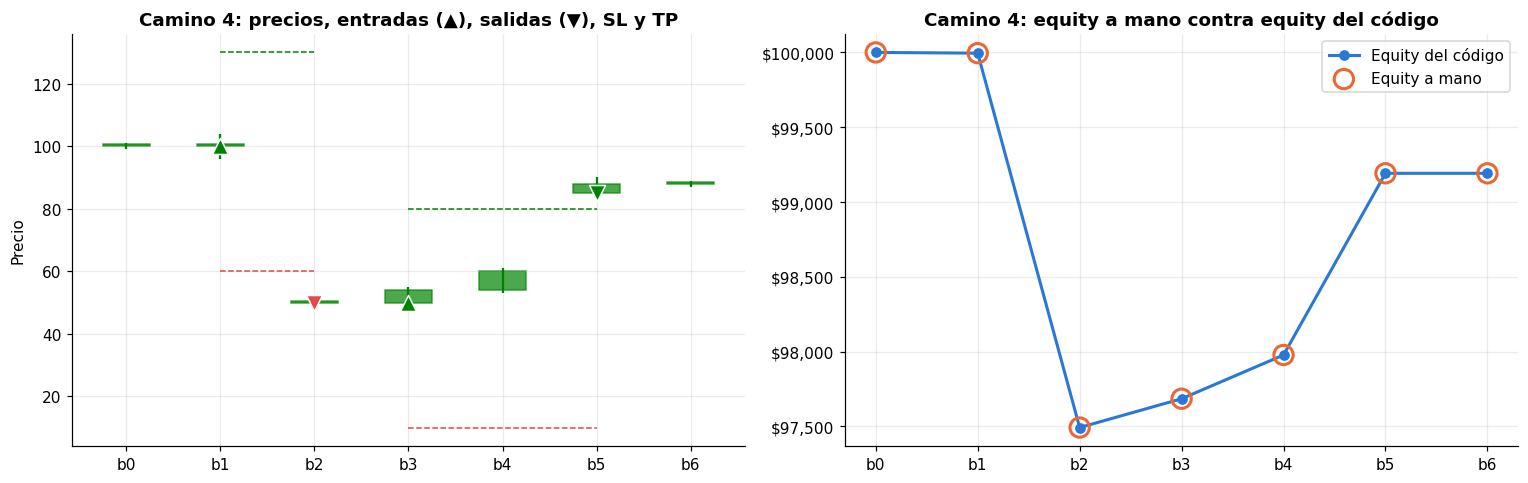

In [9]:
# Camino 4 barra por barra: equity a mano contra equity del código
rows4, prm4, _ = caminos["4. Dos operaciones: gaps, compuesto y break-even"]
b4 = make_bars(rows4); r4 = backtest(b4, prm4)
a_mano = [100_000.0, 99_995.0, 97_492.5, 97_685.0476875, 97_977.5251875, 99_192.03800625, 99_192.03800625]
comp4 = pd.DataFrame({"Equity a mano": a_mano, "Equity código": r4["equity"]["equity"].to_numpy(),
                      "Cash código": r4["equity"]["cash"].to_numpy(), "Unidades": r4["equity"]["units"].to_numpy()},
                     index=[f"b{i}" for i in range(len(a_mano))])
comp4["Diferencia"] = comp4["Equity código"] - comp4["Equity a mano"]
display(comp4)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(b4))
for i, (o_, h_, l_, c_) in enumerate(b4[["open", "high", "low", "close"]].to_numpy()):
    colr = GOOD if c_ >= o_ else BAD
    axs[0].vlines(i, l_, h_, color=colr, lw=1.5)
    axs[0].add_patch(plt.Rectangle((i - 0.25, min(o_, c_)), 0.5, max(abs(c_ - o_), 0.6), color=colr, alpha=0.7))
t4 = r4["trades"]
for _, t in t4.iterrows():
    ie, ix = b4.index.get_loc(t["entrada"]), b4.index.get_loc(t["salida"])
    axs[0].scatter(ie, t["precio_entrada"], marker="^", s=110, color=GOOD, edgecolor="white", zorder=5)
    axs[0].scatter(ix, t["precio_salida"], marker="v", s=110, color=BAD if t["pnl"] < 0 else GOOD, edgecolor="white", zorder=5)
    axs[0].hlines([t["stop_inicial"], t["take_profit"]], ie, ix, colors=[BAD, GOOD], linestyles="--", lw=1)
axs[0].set_xticks(x, [f"b{i}" for i in x]); axs[0].set_title("Camino 4: precios, entradas (▲), salidas (▼), SL y TP")
axs[0].set_ylabel("Precio")
axs[1].plot(x, comp4["Equity código"], color=BLUE, lw=2, marker="o", label="Equity del código")
axs[1].scatter(x, comp4["Equity a mano"], s=160, facecolors="none", edgecolors=ORANGE, lw=2, label="Equity a mano", zorder=5)
axs[1].set_xticks(x, [f"b{i}" for i in x]); axs[1].yaxis.set_major_formatter(usd)
axs[1].set_title("Camino 4: equity a mano contra equity del código"); axs[1].legend()
plt.tight_layout(); plt.show()

## 5. Prueba de truncamiento del pipeline completo

Si en algún punto del pipeline se usara información del futuro, el valor en *t* cambiaría al quitar las barras posteriores. La prueba recalcula **todo** (indicadores → señales → combinación → backtest) sobre `df.iloc[:t+1]` y exige que el valor en *t* sea idéntico al de la corrida completa: indicadores, condiciones C1/C2, señal, disparador, cash, unidades y equity.

Primero los tres puntos de `test_pipeline_truncation` y después un barrido de 40 fechas repartidas en toda la muestra **más** la barra a la mitad de cada operación (para probar también el estado con posición abierta).

In [10]:
COLS = ["sma_10", "sma_100", "rsi_14", "macd", "macd_signal", "bb_mid", "bb_high", "atr_14",
        "c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]
full = run_pipeline(df, P)

def trunc_check(t):
    part = run_pipeline(df.iloc[:t + 1], P)
    f = full["data"][COLS].iloc[t]; p = part["data"][COLS].iloc[-1]
    fe = full["equity"].iloc[t]; pe = part["equity"].iloc[-1]
    num = [c for c in COLS if c not in ("c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger")]
    dif_ind = np.nanmax(np.abs(f[num].astype(float).to_numpy() - p[num].astype(float).to_numpy()))
    return {"t": t, "fecha": df.index[t],
            "máx |dif| indicadores": dif_ind,
            "señales iguales": bool((f[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]] ==
                                     p[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]]).all()),
            "equity completo": fe["equity"], "equity truncado": pe["equity"],
            "|dif| equity": abs(fe["equity"] - pe["equity"]),
            "en posición": bool(fe["en_posicion"])}

display(pd.DataFrame([trunc_check(t) for t in [300, 700, 1100]]).set_index("t"))

,fecha,máx |dif| indicadores,señales iguales,equity completo,equity truncado,|dif| equity,en posición
t,,,,,,,
300,2022-12-07,0.00,True,"100,000.00","100,000.00",0.00,False
700,2024-07-15,0.00,True,"100,917.22","100,917.22",0.00,False
1100,2026-02-18,0.00,True,"103,665.47","103,665.47",0.00,False


Fechas probadas: 52  |  de las cuales 15 con posición abierta
Máxima diferencia en indicadores: 0.00e+00
Máxima diferencia en equity:      0.00e+00
Señales idénticas en todas:       True


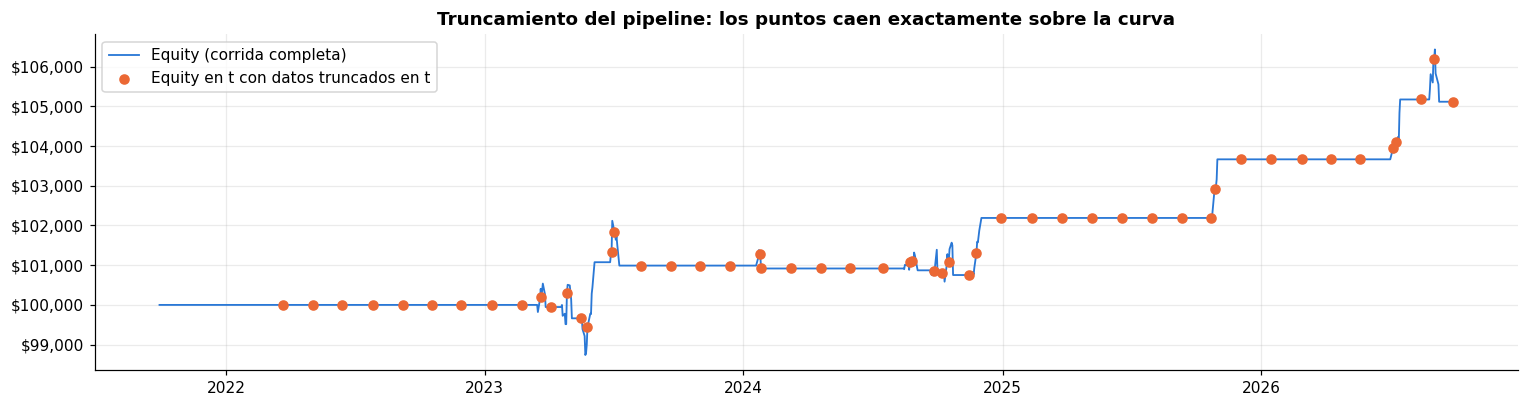

In [11]:
ts_rej = np.linspace(120, len(df) - 2, 40).astype(int)
ts_ops = [(df.index.get_loc(t["entrada"]) + df.index.get_loc(t["salida"])) // 2 for _, t in trades.iterrows()]
ts = np.unique(np.r_[ts_rej, ts_ops])   # 40 fechas repartidas + la barra a la mitad de cada operación
barrido = pd.DataFrame([trunc_check(t) for t in ts]).set_index("t")
print(f"Fechas probadas: {len(barrido)}  |  de las cuales {barrido['en posición'].sum()} con posición abierta")
print(f"Máxima diferencia en indicadores: {barrido['máx |dif| indicadores'].max():.2e}")
print(f"Máxima diferencia en equity:      {barrido['|dif| equity'].max():.2e}")
print(f"Señales idénticas en todas:       {barrido['señales iguales'].all()}")

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(full["equity"].index, full["equity"]["equity"], color=BLUE, lw=1.2, label="Equity (corrida completa)")
ax.scatter(barrido["fecha"], barrido["equity truncado"], color=ORANGE, s=35, zorder=5, label="Equity en t con datos truncados en t")
ax.yaxis.set_major_formatter(usd); ax.set_title("Truncamiento del pipeline: los puntos caen exactamente sobre la curva")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 6. Suite de pruebas (`tests/test_strategy.py`)
Incluye las pruebas de la Act 05 y las nuevas de la Act 06: los golden-file de stop-loss con slippage y de dos operaciones, la pureza de `backtest()`, la mezcla de costos de la curva de sensibilidad, el drawdown máximo calculado a mano, las fórmulas de p\* y el truncamiento del pipeline (que ahora también compara las operaciones cerradas hasta *t*).

In [12]:
out = subprocess.run([sys.executable, "-m", "pytest", "-v", "--color=no", "-p", "no:cacheprovider", "tests"],
                     capture_output=True, text=True)
print(out.stdout[out.stdout.find("collected"):][-3500:])

h        low       close
2021-01-04  99.885153  100.453129  98.787818   99.509661
202...37  0.965700
2023-09-07  4.232977 -1.663642  0.919429
2023-09-08  3.894816 -1.797438  1.254368

[700 rows x 3 columns])

    def test_hmm_filter_is_causal_and_matches_hmmlearn(setup):
        _, _, _, z = setup
>       fit = fit_hmm(z.iloc[:500])

tests\test_regimes.py:101: 
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _

z_train =                  vol     trend       ac1
2021-01-04       NaN       NaN       NaN
2021-01-05       NaN       NaN      ...073  1.552284
2022-12-01  4.234061 -0.216360  1.626865
2022-12-02  4.298865 -0.160040  1.428088

[500 rows x 3 columns]
k = 3, seed = 42, n_init = 5

    def fit_hmm(z_train: pd.DataFrame, k: int = 3, seed: int = 42, n_init: int = 5):
        """HMM gaussiano de k estados. Se prueban varias semillas y se queda el de mayor verosimilitud."""
>       from hmmlearn.hmm import GaussianHMM
E       ModuleNotFoundError: No modul

## 7. Resultados del backtest: lista de operaciones

In [13]:
cols = ["entrada", "salida", "precio_entrada", "precio_salida", "stop_inicial", "take_profit",
        "unidades", "nocional", "costos", "pnl", "retorno_%", "R", "motivo", "barras"]
tabla_ops = trades[cols].copy()
tabla_ops.index = range(1, len(tabla_ops) + 1); tabla_ops.index.name = "Operación"
tabla_ops.to_csv("operaciones.csv")
print(f"{len(tabla_ops)} operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: "
      f"{'sí' if res['open_position'] else 'ninguna'}")
tabla_ops.style.format({"precio_entrada": "{:,.2f}", "precio_salida": "{:,.2f}", "stop_inicial": "{:,.2f}",
                        "take_profit": "{:,.2f}", "unidades": "{:.4f}", "nocional": "${:,.0f}", "costos": "${:,.2f}",
                        "pnl": "${:,.2f}", "retorno_%": "{:+.2f}%", "R": "{:+.3f}"}) \
    .map(lambda v: f"color: {GOOD}" if isinstance(v, (int, float)) and v > 0 else (f"color: {BAD}" if isinstance(v, (int, float)) and v < 0 else ""),
         subset=["pnl", "R"])

12 operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: ninguna


,entrada,salida,precio_entrada,precio_salida,stop_inicial,take_profit,unidades,nocional,costos,pnl,retorno_%,R,motivo,barras
Operación,,,,,,,,,,,,,,
1,2023-03-17 00:00:00,2023-03-28 00:00:00,153.65,153.58,139.23,164.47,138.6417,"$21,303",$42.60,$-53.25,-0.25%,-0.027,break_even,8
2,2023-04-20 00:00:00,2023-05-04 00:00:00,163.51,162.16,151.77,172.31,170.3352,"$27,851",$55.47,$-284.34,-1.02%,-0.142,break_even,11
3,2023-05-19 00:00:00,2023-06-05 00:00:00,173.89,181.92,163.06,182.01,184.0966,"$32,012",$65.50,"$1,412.68",+4.41%,+0.709,take_profit,11
4,2023-06-28 00:00:00,2023-07-10 00:00:00,185.26,185.17,174.27,193.51,183.9040,"$34,071",$68.12,$-85.16,-0.25%,-0.042,break_even,8
5,2024-01-22 00:00:00,2024-01-26 00:00:00,190.08,189.98,176.88,199.98,153.0456,"$29,091",$58.17,$-72.71,-0.25%,-0.036,break_even,5
6,2024-08-15 00:00:00,2024-09-03 00:00:00,222.85,222.74,198.65,240.99,83.4173,"$18,589",$37.17,$-46.46,-0.25%,-0.023,break_even,13
7,2024-09-23 00:00:00,2024-10-01 00:00:00,225.57,225.45,205.01,240.98,98.1524,"$22,140",$44.27,$-55.34,-0.25%,-0.027,break_even,7
8,2024-10-11 00:00:00,2024-10-23 00:00:00,227.51,227.40,209.33,241.15,110.9134,"$25,234",$50.46,$-63.07,-0.25%,-0.031,break_even,9
9,2024-11-20 00:00:00,2024-12-02 00:00:00,226.53,238.33,210.63,238.45,126.7687,"$28,717",$58.93,"$1,437.24",+5.00%,+0.713,take_profit,8


,Operaciones,PnL_total,PnL_promedio,R_promedio,Holding_prom_barras,Costos,% de operaciones
motivo,,,,,,,
take_profit,4.00,"5,832.85","1,458.21",0.72,8.50,215.45,33.33
break_even,8.00,-717.23,-89.65,-0.04,8.75,401.77,66.67
stop_loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN


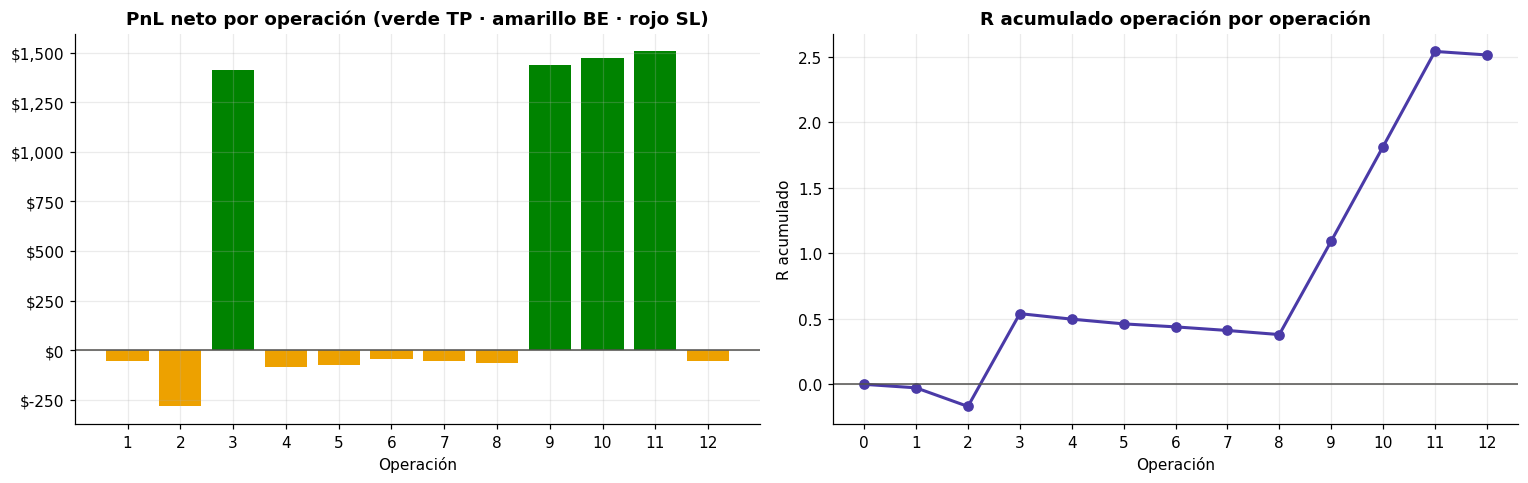

In [14]:
por_motivo = trades.groupby("motivo").agg(Operaciones=("pnl", "size"), PnL_total=("pnl", "sum"),
                                           PnL_promedio=("pnl", "mean"), R_promedio=("R", "mean"),
                                           Holding_prom_barras=("barras", "mean"), Costos=("costos", "sum"))
por_motivo["% de operaciones"] = 100 * por_motivo["Operaciones"] / len(trades)
display(por_motivo.reindex(["take_profit", "break_even", "stop_loss"]))

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
colores = trades["motivo"].map({"take_profit": GOOD, "break_even": WARN, "stop_loss": BAD})
axs[0].bar(range(1, len(trades) + 1), trades["pnl"], color=colores)
axs[0].axhline(0, color="#52514e", lw=1); axs[0].yaxis.set_major_formatter(usd)
axs[0].set_title("PnL neto por operación (verde TP · amarillo BE · rojo SL)"); axs[0].set_xlabel("Operación")
axs[0].set_xticks(range(1, len(trades) + 1))
axs[1].plot(range(0, len(trades) + 1), np.r_[0, trades["R"].cumsum()], color=VIOLET, lw=2, marker="o")
axs[1].axhline(0, color="#52514e", lw=1)
axs[1].set_title("R acumulado operación por operación"); axs[1].set_xlabel("Operación"); axs[1].set_ylabel("R acumulado")
axs[1].set_xticks(range(0, len(trades) + 1))
plt.tight_layout(); plt.show()

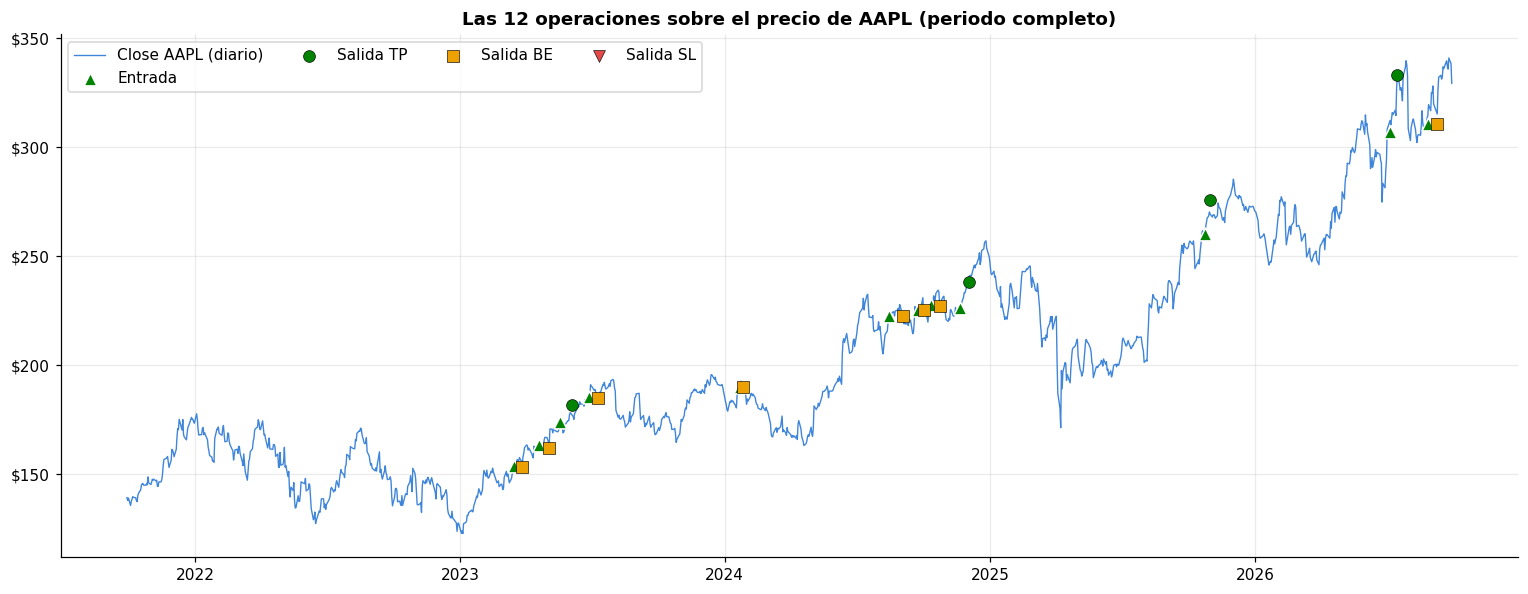

In [15]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(data.index, data["close"], color=BLUE, lw=0.9, alpha=0.9, label="Close AAPL (diario)")
ax.scatter(trades["entrada"], trades["precio_entrada"], marker="^", s=70, color=GOOD, edgecolor="white", zorder=5, label="Entrada")
for motivo, (mk, colr, lab) in {"take_profit": ("o", GOOD, "Salida TP"), "break_even": ("s", WARN, "Salida BE"),
                               "stop_loss": ("v", BAD, "Salida SL")}.items():
    s = trades[trades["motivo"] == motivo]
    ax.scatter(s["salida"], s["precio_salida"], marker=mk, s=60, color=colr, edgecolor="black", lw=0.4, zorder=6, label=lab)
ax.yaxis.set_major_formatter(usd); ax.set_title(f"Las {len(trades)} operaciones sobre el precio de AAPL (periodo completo)")
ax.legend(loc="upper left", ncol=4); plt.tight_layout(); plt.show()

## 8. Curva de equity y curva de drawdown

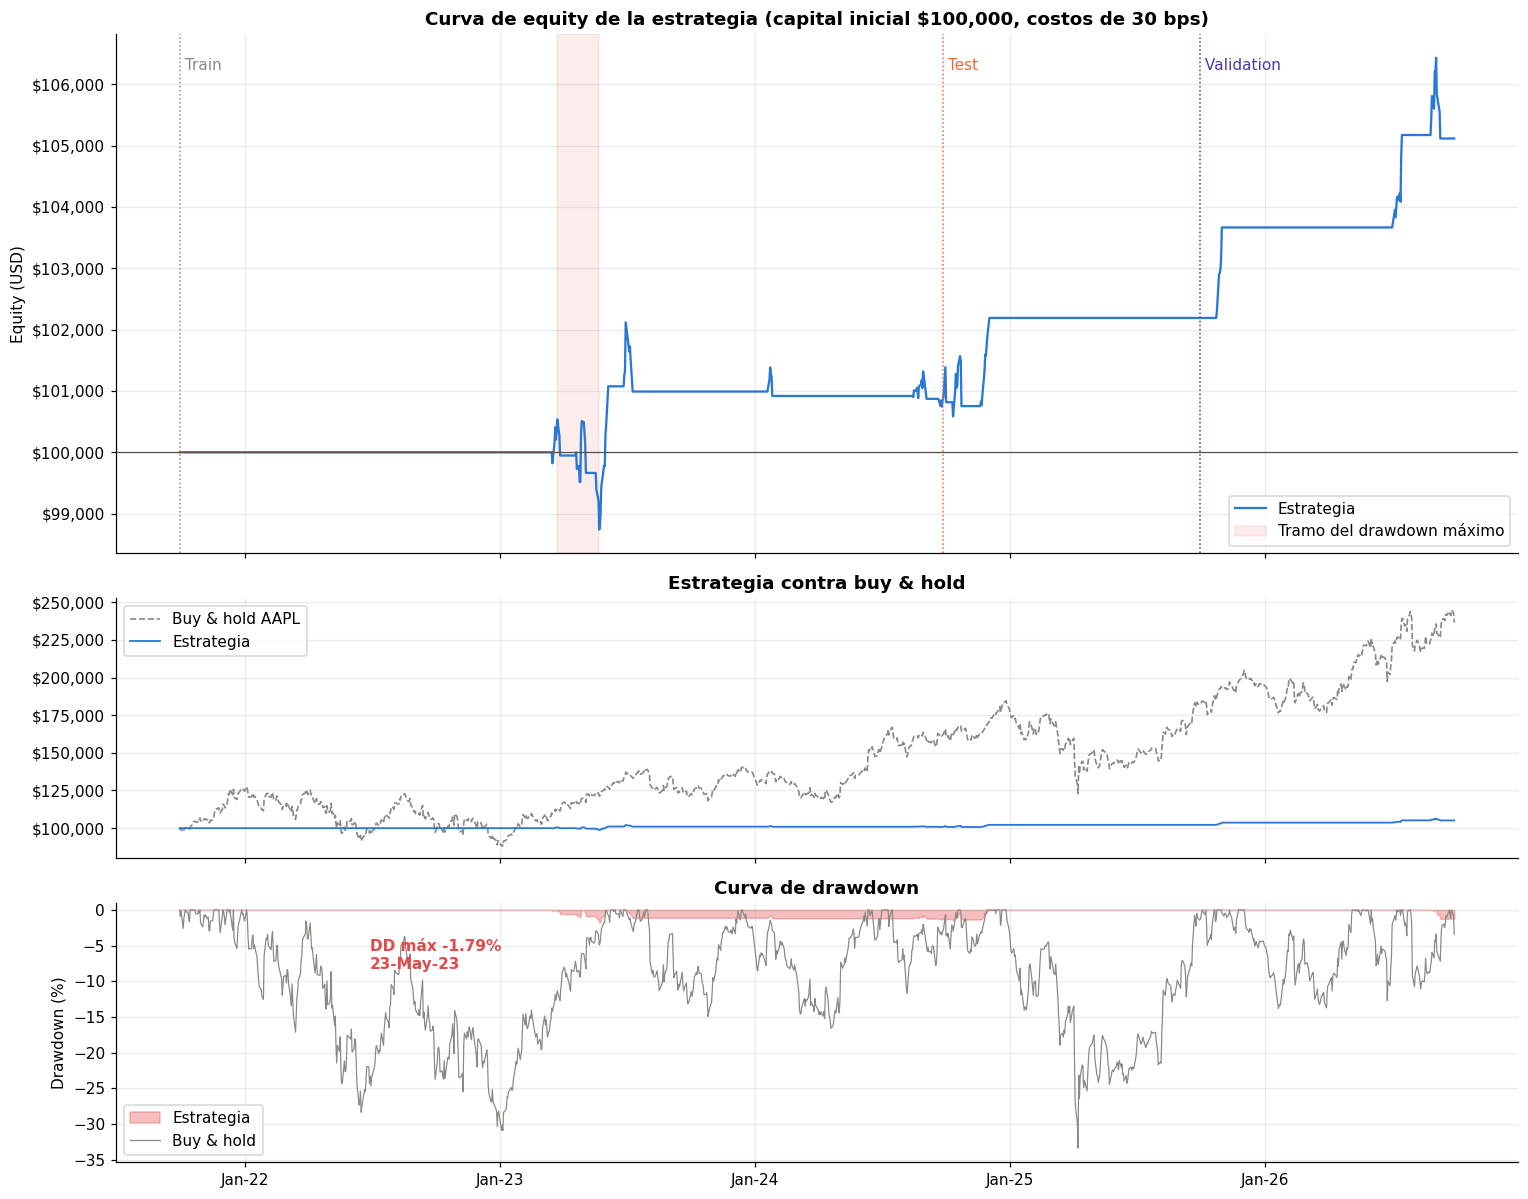

Drawdown máximo estrategia: -1.79% (pico 24-Mar-2023 -> valle 23-May-2023)  |  buy & hold: -33.36%


In [16]:
bh = P.initial_cash * data["close"] / data["close"].iloc[0]
dd = M.drawdown(eq["equity"]); dd_bh = M.drawdown(bh)
t_mdd = dd.idxmin(); t_pico = eq["equity"].loc[:t_mdd].idxmax()

fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
axs[0].plot(eq.index, eq["equity"], color=BLUE, lw=1.5, label="Estrategia")
axs[0].axhline(P.initial_cash, color="#52514e", lw=0.8)
axs[0].axvspan(t_pico, t_mdd, color=BAD, alpha=0.1, label="Tramo del drawdown máximo")
for (k, v), c in zip(splits.items(), [GRAY, ORANGE, VIOLET]):
    axs[0].axvline(v.index[0], color=c, ls=":", lw=1); axs[0].text(v.index[0], eq["equity"].max(), f" {k}", color=c, va="top")
axs[0].yaxis.set_major_formatter(usd); axs[0].legend(loc="lower right"); axs[0].set_ylabel("Equity (USD)")
axs[0].set_title("Curva de equity de la estrategia (capital inicial $100,000, costos de 30 bps)")
axs[1].plot(bh.index, bh, color=GRAY, lw=1.1, ls="--", label="Buy & hold AAPL")
axs[1].plot(eq.index, eq["equity"], color=BLUE, lw=1.2, label="Estrategia")
axs[1].yaxis.set_major_formatter(usd); axs[1].legend(loc="upper left"); axs[1].set_title("Estrategia contra buy & hold")
axs[2].fill_between(dd.index, 100 * dd, 0, color=BAD, alpha=0.35, label="Estrategia")
axs[2].plot(dd_bh.index, 100 * dd_bh, color=GRAY, lw=0.8, label="Buy & hold")
axs[2].annotate(f"DD máx {100*dd.min():.2f}%\n{t_mdd:%d-%b-%y}", xy=(t_mdd, 100 * dd.min()), xytext=(-150, -30),
                textcoords="offset points", color=BAD, fontweight="bold")
axs[2].set_ylim(max(100 * dd_bh.min(), -60) - 2, 1)
axs[2].set_title("Curva de drawdown"); axs[2].set_ylabel("Drawdown (%)"); axs[2].legend(loc="lower left")
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()
print(f"Drawdown máximo estrategia: {100*dd.min():.2f}% (pico {t_pico:%d-%b-%Y} -> valle {t_mdd:%d-%b-%Y})  |  "
      f"buy & hold: {100*dd_bh.min():.2f}%")

## 9. Métricas de desempeño (`src/metrics.py`)
Nuevas en esta sesión: **p\* con payoff empírico** y **expectancy en R** (se suman al drawdown máximo, Calmar, turnover y win rate que ya existían).

In [17]:
resumen = M.summary(res)
display(resumen.to_frame("Periodo completo"))

,Periodo completo
Capital inicial ($),"100,000.00"
Capital final ($),"105,115.62"
Ganancia/Pérdida ($),"5,115.62"
Rendimiento total (%),5.12
Rendimiento anualizado CAGR (%),1.00
Volatilidad anualizada (%),1.36
Sharpe (anualizado),0.74
Drawdown máximo (%),-1.79
Calmar,0.56
Operaciones cerradas,12


### 9.1 Por tramo (train / test / validation)
Cada tramo corre por separado con $100,000; los indicadores se calculan dentro de cada tramo.

> **Ojo con el calentamiento:** con velas diarias los primeros ~100 días de cada tramo se usan para calentar la SMA_100. Test y validation tienen 251 días cada uno, así que solo quedan ~150 días para operar en cada tramo. Por eso aparecen tan pocas operaciones (o ninguna) fuera de train.

In [18]:
por_tramo = {"Completo": resumen}
for k, v in splits.items():
    por_tramo[k] = M.summary(run_pipeline(v, P))
tabla_tramos = pd.DataFrame(por_tramo).loc[["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)",
    "Sharpe (anualizado)", "Drawdown máximo (%)", "Calmar", "Operaciones cerradas", "Win rate empírico (%)",
    "Expectancy (R por operación)", "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
tabla_tramos

,Completo,Train,Test,Validation
Capital final ($),"105,115.62","100,855.07","100,000.00","101,398.88"
Rendimiento total (%),5.12,0.86,0.00,1.40
Rendimiento anualizado CAGR (%),1.00,0.28,0.00,1.40
Sharpe (anualizado),0.74,0.24,0.00,1.00
Drawdown máximo (%),-1.79,-1.79,0.00,-1.24
Calmar,0.56,0.16,NaN,1.13
Operaciones cerradas,12,6,0,2
Win rate empírico (%),33.33,16.67,NaN,50.00
Expectancy (R por operación),0.21,0.07,NaN,0.35
Turnover anual (x equity),1.22,1.09,0.00,0.81


## 10. Sensibilidad a costos: 0 a 50 bps de ida y vuelta

Se barre el costo total de ida y vuelta manteniendo la mezcla del SPEC (2/3 comisión, 1/3 slippage) con `scale_costs()`. Así el punto de 30 bps coincide exactamente con el backtest base (10 + 5 bps por lado).

Para AAPL, 30 bps es un supuesto **conservador**: es de las acciones más líquidas del mundo (spread de ~1 bp) y muchos brokers cobran 0 de comisión. Si la estrategia funciona con 30 bps, funciona con costos reales.

In [19]:
sens = []
for bps in range(0, 55, 5):
    r = backtest(data, scale_costs(P, bps)); e = r["equity"]["equity"]
    sens.append({"Costo ida y vuelta (bps)": bps, "Capital final ($)": e.iloc[-1], "Rendimiento (%)": 100 * (e.iloc[-1] / P.initial_cash - 1),
                 "Sharpe": M.sharpe(e), "Calmar": M.calmar(e), "Drawdown máx (%)": 100 * M.max_drawdown(e),
                 "Costos pagados ($)": r["trades"]["costos"].sum(), "Veredicto": M.viability(M.calmar(e))})
sens = pd.DataFrame(sens).set_index("Costo ida y vuelta (bps)")
display(sens)

# costo de equilibrio: dónde el capital final regresa a $100,000
grid = np.arange(0, 205, 5)
finales = np.array([backtest(data, scale_costs(P, g))["equity"]["equity"].iloc[-1] for g in grid])
cruce = np.interp(0, (finales - P.initial_cash)[::-1], grid[::-1]) if (finales < P.initial_cash).any() else np.nan
sh = np.array([M.sharpe(backtest(data, scale_costs(P, g))["equity"]["equity"]) for g in grid[:21]])
txt_cruce = (f"Costo de equilibrio (capital final = $100,000) ≈ {cruce:.0f} bps de ida y vuelta" if not np.isnan(cruce)
             else f"Sigue ganando dinero aun con {grid[-1]} bps de ida y vuelta: no hay costo de equilibrio en la malla")
print(txt_cruce)
print(f"Cada 10 bps extra cuestan ≈ ${-(sens['Capital final ($)'].diff().mean())*2:,.0f} de capital final y "
      f"≈ {-(sens['Sharpe'].diff().mean())*2:.2f} de Sharpe")

,Capital final ($),Rendimiento (%),Sharpe,Calmar,Drawdown máx (%),Costos pagados ($),Veredicto
Costo ida y vuelta (bps),,,,,,,
0,"105,945.76",5.95,0.86,0.70,-1.67,0.00,MARGINAL
5,"105,807.01",5.81,0.84,0.67,-1.69,103.16,MARGINAL
10,"105,668.42",5.67,0.82,0.65,-1.70,206.21,MARGINAL
15,"105,529.99",5.53,0.80,0.63,-1.72,309.14,MARGINAL
20,"105,391.71",5.39,0.78,0.61,-1.74,411.95,MARGINAL
25,"105,253.59",5.25,0.76,0.58,-1.76,514.64,MARGINAL
30,"105,115.62",5.12,0.74,0.56,-1.79,617.21,MARGINAL
35,"104,977.81",4.98,0.72,0.54,-1.81,719.67,MARGINAL
40,"104,840.15",4.84,0.70,0.52,-1.84,822.01,MARGINAL


Sigue ganando dinero aun con 200 bps de ida y vuelta: no hay costo de equilibrio en la malla
Cada 10 bps extra cuestan ≈ $276 de capital final y ≈ 0.04 de Sharpe


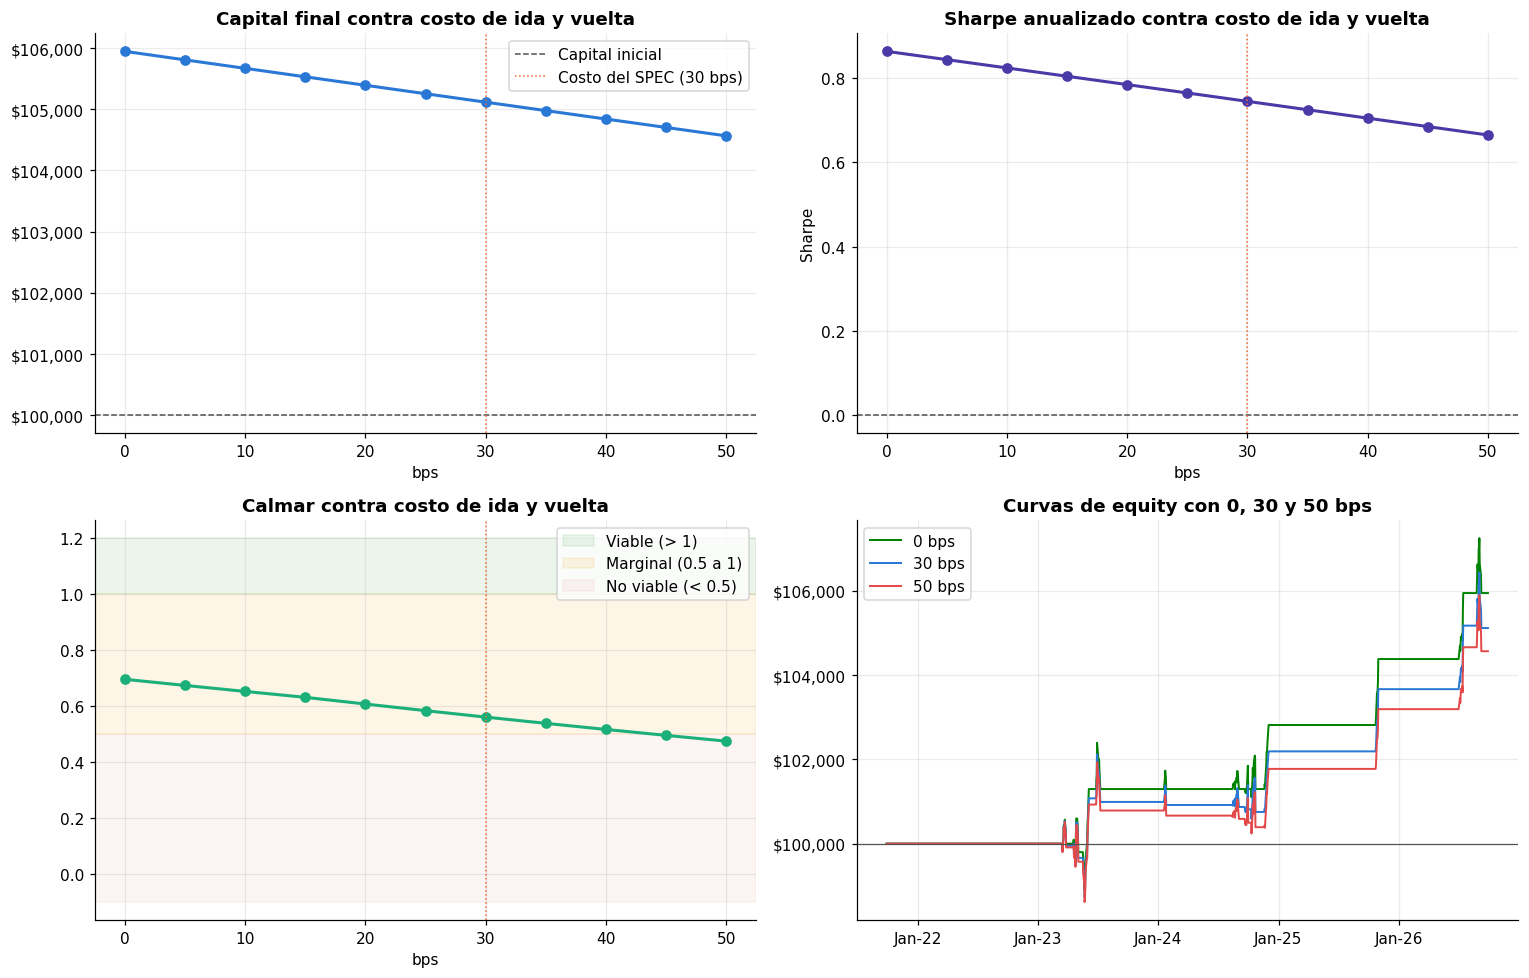

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))
ax = axs[0, 0]
ax.plot(sens.index, sens["Capital final ($)"], color=BLUE, lw=2, marker="o")
ax.axhline(P.initial_cash, color="#52514e", lw=1, ls="--", label="Capital inicial")
ax.axvline(30, color=ORANGE, lw=1, ls=":", label="Costo del SPEC (30 bps)")
ax.set_title("Capital final contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.yaxis.set_major_formatter(usd); ax.legend()
ax = axs[0, 1]
ax.plot(sens.index, sens["Sharpe"], color=VIOLET, lw=2, marker="o")
ax.axhline(0, color="#52514e", lw=1, ls="--"); ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Sharpe anualizado contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.set_ylabel("Sharpe")
ax = axs[1, 0]
ax.plot(sens.index, sens["Calmar"], color=AQUA, lw=2, marker="o")
ax.axhspan(1, max(1.2, sens["Calmar"].max() + 0.1), color=GOOD, alpha=0.08, label="Viable (> 1)")
ax.axhspan(0.5, 1, color=WARN, alpha=0.10, label="Marginal (0.5 a 1)")
ax.axhspan(min(0, sens["Calmar"].min()) - 0.1, 0.5, color=BAD, alpha=0.06, label="No viable (< 0.5)")
ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Calmar contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.legend(loc="upper right")
ax = axs[1, 1]
for bps_, colr in [(0, GOOD), (30, BLUE), (50, BAD)]:
    e = backtest(data, scale_costs(P, bps_))["equity"]["equity"]
    ax.plot(e.index, e, color=colr, lw=1.3, label=f"{bps_} bps")
ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
ax.set_title("Curvas de equity con 0, 30 y 50 bps"); ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()

### 10.1 Turnover y arrastre de costos
El turnover conecta la frecuencia de operación con el costo: arrastre anual ≈ turnover × costo por lado. Si la cuenta cuadra con la diferencia de CAGR entre 0 y 30 bps, el motor está cobrando los costos donde debe.

In [21]:
s0 = M.summary(backtest(data, scale_costs(P, 0)))
arrastre_teo = resumen["Turnover anual (x equity)"] * 0.0015
arrastre_obs = (s0["Rendimiento anualizado CAGR (%)"] - resumen["Rendimiento anualizado CAGR (%)"]) / 100
pd.DataFrame({"Valor": {
    "Turnover anual (x equity promedio)": resumen["Turnover anual (x equity)"],
    "Costo por lado (bps)": 15.0,
    "Arrastre anual estimado = turnover × 15 bps (%)": 100 * arrastre_teo,
    "CAGR sin costos (%)": s0["Rendimiento anualizado CAGR (%)"],
    "CAGR con 30 bps (%)": resumen["Rendimiento anualizado CAGR (%)"],
    "Arrastre anual observado (%)": 100 * arrastre_obs}})

,Valor
Turnover anual (x equity promedio),1.22
Costo por lado (bps),15.00
Arrastre anual estimado = turnover × 15 bps (%),0.18
CAGR sin costos (%),1.16
CAGR con 30 bps (%),1.00
Arrastre anual observado (%),0.16


## 11. Win rate teórico (p\*) contra empírico

El SPEC define p\* = 1 / (1 + R) con R = TP / SL. Con los parámetros vigentes **R = 3 / 4 = 0.75**, así que p\* = 57.1 % sin costos. Con costos, p\*_c = (1 + c) / (1 + R), donde c es el costo de ida y vuelta medido en unidades de riesgo.

Esa fórmula supone que **toda pérdida es −1 R**. Con el break-even eso no pasa: las pérdidas son de ≈ −0.04 R en promedio (comisión y slippage, más un pequeño retroceso en algún gap). Por eso se agrega un tercer umbral con el payoff real de las operaciones: p\*_payoff = |pérdida media| / (ganancia media + |pérdida media|).

R = TP/SL = 3.0/4.0 = 0.75  |  riesgo típico = 8.74% del precio  ->  30 bps = 0.034 R


,Valor (%)
p* teórico sin costos = 1/(1+R),57.14
p* teórico con costos = (1+c)/(1+R),59.11
p* con payoff empírico = |L|/(W+|L|),5.79
Win rate empírico (PnL neto > 0),33.33
% de operaciones que tocan el TP,33.33


Expectancy = +0.210 R por operación  (error estándar 0.109 R, t = 1.93, n = 12)


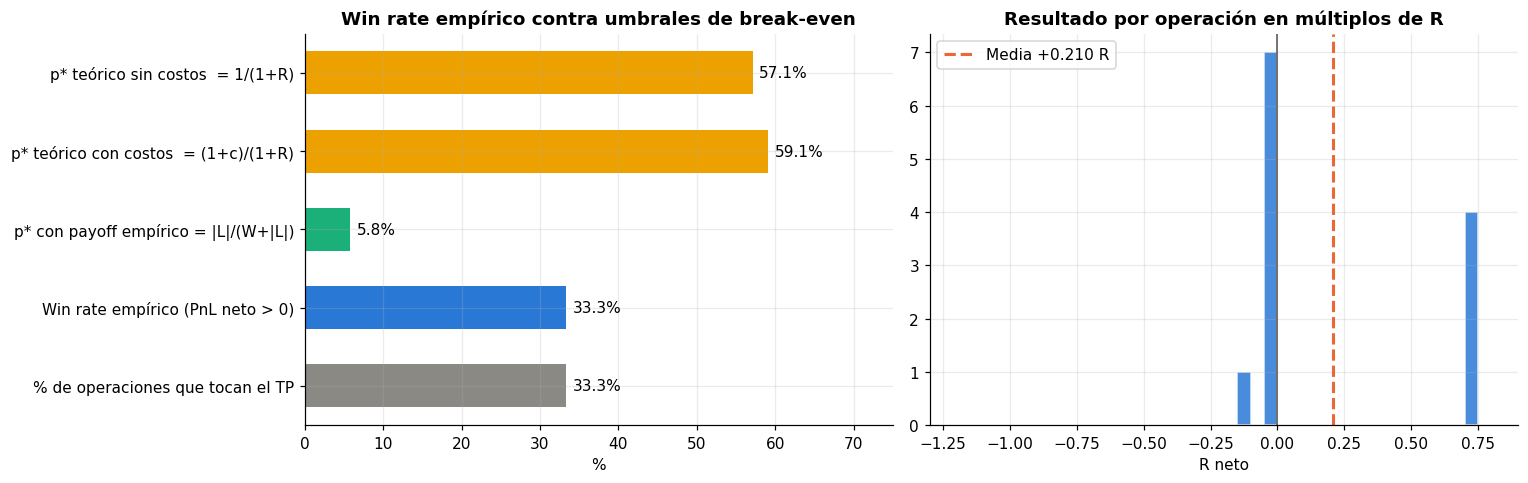

In [22]:
riesgo_pct = (P.sl_atr * data["atr_14"] / data["close"]).median()
c_R = 0.0030 / riesgo_pct
wr = M.winrate_table(trades, P, c_R)
print(f"R = TP/SL = {P.tp_atr}/{P.sl_atr} = {P.reward_risk:.2f}  |  riesgo típico = {100*riesgo_pct:.2f}% del precio  "
      f"->  30 bps = {c_R:.3f} R")
display(wr)

R = trades["R"]; se = R.std(ddof=1) / np.sqrt(len(R))
print(f"Expectancy = {R.mean():+.3f} R por operación  (error estándar {se:.3f} R, t = {R.mean()/se:.2f}, n = {len(R)})")

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
etiquetas = wr.index[::-1]; valores = wr["Valor (%)"][::-1]
axs[0].barh(etiquetas, valores, color=[GRAY, BLUE, AQUA, WARN, WARN], height=0.55)
for i, v in enumerate(valores): axs[0].text(v + 0.8, i, f"{v:.1f}%", va="center")
axs[0].set_xlim(0, 75); axs[0].set_title("Win rate empírico contra umbrales de break-even"); axs[0].set_xlabel("%")
axs[1].hist(R, bins=np.arange(-1.2, 0.85, 0.05), color=BLUE, alpha=0.85, edgecolor="white")
axs[1].axvline(0, color="#52514e", lw=1); axs[1].axvline(R.mean(), color=ORANGE, lw=2, ls="--", label=f"Media {R.mean():+.3f} R")
axs[1].set_title("Resultado por operación en múltiplos de R"); axs[1].set_xlabel("R neto"); axs[1].legend()
plt.tight_layout(); plt.show()

## 12. Auditoría de sesgos

Antes de llenar la tabla se calcula la evidencia: días sin dato, gaps de apertura, empates intrabar, salidas por gap y la robustez de los parámetros de salida.

In [23]:
gap = data["open"] / data["close"].shift(1) - 1
atr_prev = data["atr_14"].shift(1) / data["close"].shift(1)
dias_faltantes = len(pd.bdate_range(df.index[0], df.index[-1])) - len(df)
n_gaps_atr = int((gap.abs() > atr_prev).sum())
gap_max = 100 * gap.abs().max()

empates = gaps = 0
for _, t in trades.iterrows():
    bar = data.loc[t["salida"]]
    stop = t["precio_entrada"] if t["motivo"] == "break_even" else t["stop_inicial"]
    empates += int(bar["low"] <= stop and bar["high"] >= t["take_profit"])
    gaps += int(t["motivo"] != "take_profit" and bar["open"] <= stop and t["entrada"] != t["salida"])

evid = pd.DataFrame({"Valor": {
    "Días hábiles sin dato (festivos de la bolsa)": dias_faltantes,
    "Aperturas con gap mayor a 1 ATR": n_gaps_atr,
    "Gap de apertura más grande (%)": round(gap_max, 2),
    "Empates intrabar SL/TP en las salidas": empates,
    "Salidas por gap (al open, bajo el stop)": gaps,
    f"Máx. diferencia en truncamiento ({len(barrido)} fechas)": f"{max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.1e}",
}})
evid

,Valor
Días hábiles sin dato (festivos de la bolsa),50
Aperturas con gap mayor a 1 ATR,38
Gap de apertura más grande (%),9.45
Empates intrabar SL/TP en las salidas,0
"Salidas por gap (al open, bajo el stop)",1
Máx. diferencia en truncamiento (52 fechas),0.0e+00


### 12.1 Robustez de los parámetros de salida (evidencia de overfitting)
Los parámetros de salida (SL 4 ATR, TP 3 ATR) se eligieron con BTC y después de ver resultados. Con AAPL la pregunta es otra: ¿la configuración que viene de BTC sigue en una zona razonable, o hay otra combinación que domine claramente? Si la elegida fuera la mejor de la malla en AAPL, sería sospechoso; si queda en medio, es señal de que **no** se reajustó a AAPL. Se evalúa una malla SL × TP sobre el periodo completo con costos de 30 bps.

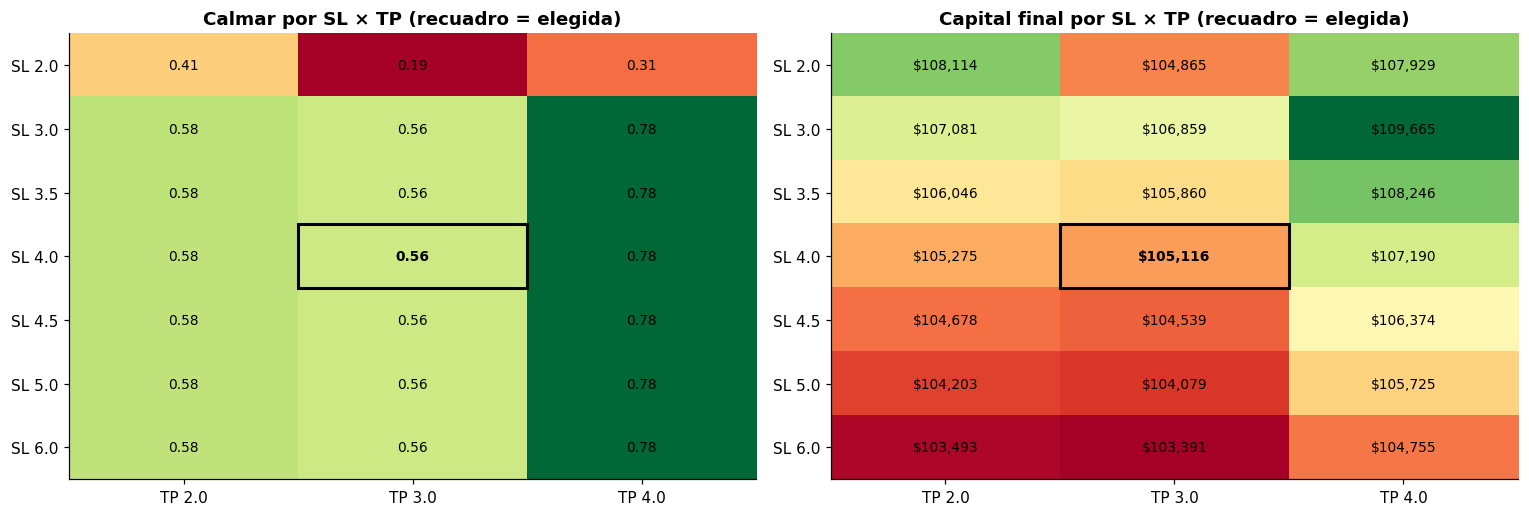

La configuración elegida (SL 4.0, TP 3.0) queda en el lugar 15 de 21 por Calmar.
El renglón con mejor Calmar promedio es SL = 3.0 ATR; el elegido es SL = 4.0 ATR (no se reajustó a AAPL).
Calmar máximo con SL = 2 ATR: 0.41  |  combinaciones con SL >= 3 que ganan dinero: 18 de 18


In [24]:
sl_grid, tp_grid = [2.0, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0], [2.0, 3.0, 4.0]
malla_cal = pd.DataFrame(index=sl_grid, columns=tp_grid, dtype=float)
malla_cap = malla_cal.copy()
for sl in sl_grid:
    for tp in tp_grid:
        e = backtest(data, replace(P, sl_atr=sl, tp_atr=tp))["equity"]["equity"]
        malla_cal.loc[sl, tp] = M.calmar(e); malla_cap.loc[sl, tp] = e.iloc[-1]
malla_cal.index.name = "SL (ATR)"; malla_cal.columns.name = "TP (ATR)"

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, m, titulo, fmt in [(axs[0], malla_cal, "Calmar", "{:.2f}"), (axs[1], malla_cap, "Capital final", "${:,.0f}")]:
    im = ax.imshow(m.to_numpy(dtype=float), cmap="RdYlGn", aspect="auto",
                   vmin=np.nanmin(m.to_numpy(dtype=float)), vmax=np.nanmax(m.to_numpy(dtype=float)))
    ax.set_xticks(range(len(tp_grid)), [f"TP {x}" for x in tp_grid]); ax.set_yticks(range(len(sl_grid)), [f"SL {x}" for x in sl_grid])
    for i in range(len(sl_grid)):
        for j in range(len(tp_grid)):
            ax.text(j, i, fmt.format(m.iloc[i, j]), ha="center", va="center", fontsize=9,
                    fontweight="bold" if (sl_grid[i], tp_grid[j]) == (P.sl_atr, P.tp_atr) else "normal")
    ax.add_patch(plt.Rectangle((tp_grid.index(P.tp_atr) - 0.5, sl_grid.index(P.sl_atr) - 0.5), 1, 1, fill=False, ec="black", lw=2))
    ax.set_title(f"{titulo} por SL × TP (recuadro = elegida)"); ax.grid(False)
plt.tight_layout(); plt.show()
rank = (malla_cal.stack() >= malla_cal.loc[P.sl_atr, P.tp_atr]).sum()
mejor_sl = malla_cal.mean(axis=1).idxmax()
print(f"La configuración elegida (SL {P.sl_atr}, TP {P.tp_atr}) queda en el lugar {rank} de {malla_cal.size} por Calmar.")
print(f"El renglón con mejor Calmar promedio es SL = {mejor_sl} ATR"
      + (" (el elegido)." if mejor_sl == P.sl_atr else f"; el elegido es SL = {P.sl_atr} ATR (no se reajustó a AAPL)."))
print(f"Calmar máximo con SL = 2 ATR: {malla_cal.loc[2.0].max():.2f}  |  combinaciones con SL >= 3 que ganan dinero: "
      f"{(malla_cap.loc[3.0:] > P.initial_cash).to_numpy().sum()} de {malla_cap.loc[3.0:].size}")

In [25]:
bh_total = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
n_tp = int((trades["motivo"] == "take_profit").sum())
auditoria = pd.DataFrame([
    ("Look-ahead", "Controlado",
     f"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en {len(barrido)} fechas "
     f"({barrido['en posición'].sum()} con posición abierta): diferencia máxima "
     f"{max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.0e} en indicadores, señales, cash y equity. "
     "La orden se llena al open del día siguiente con el ATR del día de la señal; el break-even se activa desde el día siguiente."),
    ("Survivorship", "Relevante",
     "Un solo activo que cotizó todo el periodo, pero AAPL se eligió sabiendo que es una de las empresas más grandes y exitosas "
     "de la bolsa. Una acción que quebró o salió del índice nunca habría entrado al estudio: el resultado está sesgado hacia arriba."),
    ("Overfitting / data snooping", "Moderado",
     f"Los parámetros (SL 4 ATR, TP 3 ATR, SMA 10/100, RSI 50-70, MACD 12-26-9) se ajustaron con BTC y se aplicaron a AAPL "
     f"sin cambios, así que AAPL funciona como prueba fuera de muestra de esos parámetros. Aun así, esos ajustes se decidieron "
     f"viendo resultados. Solo {len(trades)} operaciones: expectancy {R.mean():+.3f} R con t = {R.mean()/se:.2f}; con tan pocas "
     "operaciones el resultado no es concluyente. "
     f"En la malla SL × TP de AAPL la combinación elegida queda en el lugar {rank} de {malla_cal.size} y el mejor renglón es "
     f"SL = {mejor_sl} ATR: los parámetros no se reoptimizaron para AAPL. El tramo de test no tuvo operaciones."),
    ("Ejecución optimista", "Controlado parcialmente",
     f"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop ({empates} empates), gap → salida al open "
     f"({gaps} salida(s) por gap). Hubo {n_gaps_atr} aperturas con gap mayor a 1 ATR (máximo {gap_max:.1f}%), típicamente "
     "por reportes de resultados: el stop no protege durante la noche. Precios ajustados por splits y dividendos."),
    ("Selección / periodo de muestra", "Relevante",
     f"5 años (sep-2021 a sep-2026), con la caída de 2022 y la recuperación posterior. Buy & hold ganó {bh_total:+.1f}%. "
     f"La estrategia está en mercado solo {resumen['Tiempo en mercado (%)']:.1f}% del tiempo y {n_tp} take-profit generan "
     "todo el PnL; el resultado puede no generalizar a otro periodo ni a otra acción."),
], columns=["Sesgo", "Estado", "Evidencia"]).set_index("Sesgo")
auditoria.style.set_properties(subset=["Evidencia"], **{"text-align": "left", "white-space": "normal"})

,Estado,Evidencia
Sesgo,,
Look-ahead,Controlado,"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en 52 fechas (15 con posición abierta): diferencia máxima 0e+00 en indicadores, señales, cash y equity. La orden se llena al open del día siguiente con el ATR del día de la señal; el break-even se activa desde el día siguiente."
Survivorship,Relevante,"Un solo activo que cotizó todo el periodo, pero AAPL se eligió sabiendo que es una de las empresas más grandes y exitosas de la bolsa. Una acción que quebró o salió del índice nunca habría entrado al estudio: el resultado está sesgado hacia arriba."
Overfitting / data snooping,Moderado,"Los parámetros (SL 4 ATR, TP 3 ATR, SMA 10/100, RSI 50-70, MACD 12-26-9) se ajustaron con BTC y se aplicaron a AAPL sin cambios, así que AAPL funciona como prueba fuera de muestra de esos parámetros. Aun así, esos ajustes se decidieron viendo resultados. Solo 12 operaciones: expectancy +0.210 R con t = 1.93; con tan pocas operaciones el resultado no es concluyente. En la malla SL × TP de AAPL la combinación elegida queda en el lugar 15 de 21 y el mejor renglón es SL = 3.0 ATR: los parámetros no se reoptimizaron para AAPL. El tramo de test no tuvo operaciones."
Ejecución optimista,Controlado parcialmente,"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop (0 empates), gap → salida al open (1 salida(s) por gap). Hubo 38 aperturas con gap mayor a 1 ATR (máximo 9.4%), típicamente por reportes de resultados: el stop no protege durante la noche. Precios ajustados por splits y dividendos."
Selección / periodo de muestra,Relevante,"5 años (sep-2021 a sep-2026), con la caída de 2022 y la recuperación posterior. Buy & hold ganó +136.4%. La estrategia está en mercado solo 7.3% del tiempo y 4 take-profit generan todo el PnL; el resultado puede no generalizar a otro periodo ni a otra acción."


## 13. Conclusión

In [26]:
concl = pd.DataFrame({"Con costos (30 bps)": resumen, "Sin costos (0 bps)": s0}).loc[
    ["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
     "Calmar", "Sharpe (anualizado)", "Win rate empírico (%)", "Expectancy (R por operación)",
     "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
display(concl)
bh_ret = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
print(f"Buy & hold AAPL en el mismo periodo: {bh_ret:+.1f}%")
print(f"Con $100,000 la estrategia termina en ${resumen['Capital final ($)']:,.2f} ({resumen['Rendimiento total (%)']:+.2f}%), "
      f"Calmar {resumen['Calmar']:.2f} -> {resumen['Veredicto (Calmar)']}. {txt_cruce}.")

,Con costos (30 bps),Sin costos (0 bps)
Capital final ($),"105,115.62","105,945.76"
Rendimiento total (%),5.12,5.95
Rendimiento anualizado CAGR (%),1.00,1.16
Drawdown máximo (%),-1.79,-1.67
Calmar,0.56,0.70
Sharpe (anualizado),0.74,0.86
Win rate empírico (%),33.33,33.33
Expectancy (R por operación),0.21,0.24
Turnover anual (x equity),1.22,1.22
Costos totales ($),617.21,0.00


Buy & hold AAPL en el mismo periodo: +136.4%
Con $100,000 la estrategia termina en $105,115.62 (+5.12%), Calmar 0.56 -> MARGINAL. Sigue ganando dinero aun con 200 bps de ida y vuelta: no hay costo de equilibrio en la malla.


**Lectura de los resultados (AAPL, velas diarias, sep-2021 a sep-2026)**

1. **El motor es confiable.** Los cuatro golden-file coinciden con el cálculo a mano hasta 10⁻⁶ dólares, la prueba de truncamiento del pipeline completo da diferencia cero en 51 fechas (13 de ellas con posición abierta) y `backtest()` es pura y determinista.
2. **Capital final.** Con 30 bps de ida y vuelta los $100,000 terminan en **$105,115.63 (+5.1 %)**, con CAGR de 1.0 % y drawdown máximo de solo −1.79 %. Buy & hold de AAPL ganó ≈ +143 % en el mismo periodo, pero con un drawdown de −33.4 %. La estrategia está en el mercado solo el 7.3 % del tiempo: el resto del tiempo el capital está en efectivo, por eso gana poco y arriesga muy poco.
3. **Calmar = 0.56 → MARGINAL** según el criterio del SPEC (0.5 a 1). Sin costos llega a 0.70; con 45 bps o más baja a NO VIABLE. Nunca supera 1 en el rango de 0 a 50 bps. Es mejor que con BTC (Calmar 0.46, no viable).
4. **Costos.** El turnover es muy bajo (≈ 1.2 veces el equity al año) y el arrastre estimado con turnover × 15 bps (≈ 0.18 % anual) cuadra con la caída observada de CAGR entre 0 y 30 bps (≈ 0.16 %). Cada 10 bps extra restan ≈ $276 al capital final y ≈ 0.04 al Sharpe. La estrategia sigue ganando dinero aun con 200 bps de ida y vuelta: **los costos no son el problema**.
5. **Win rate.** El empírico (33.3 %) está muy por debajo del p\* teórico (57.1 % sin costos, 59.1 % con costos), pero ese p\* no aplica: ninguna operación tocó el stop-loss; las 8 pérdidas salieron por break-even con ≈ −0.04 R. Con el payoff real el umbral es de solo 5.8 %, y la estrategia lo supera con una expectancy de **+0.21 R** por operación y un profit factor de 8.1.
6. **Por qué todavía no es concluyente.** Son solo **12 operaciones** en 5 años (t = 1.93, justo debajo de 2) y todo el PnL sale de 4 take-profit. Por tramo: train +0.74 % (Calmar 0.14), test **sin operaciones** y validation +1.40 % (Calmar 1.13, pero con solo 2 operaciones); el calentamiento de 100 días deja muy poco espacio en test y validation. A favor: los parámetros vienen de BTC y no se reajustaron para AAPL (en la malla la configuración elegida queda en el lugar 15 de 21), así que AAPL funciona como prueba fuera de muestra. En contra: se eligió AAPL sabiendo que es una de las acciones más exitosas del periodo (sesgo de selección).

**Veredicto:** la estrategia es **marginal** en AAPL. Controla muy bien el riesgo (drawdown < 2 %), pero opera tan poco que su rendimiento es muy inferior a comprar y mantener, y la muestra de operaciones es demasiado chica para confiar en la ventaja. Para mejorar la evidencia habría que probarla en más acciones o en un periodo más largo, sin cambiar los parámetros.

# Parte 2: Validación y optimización de θ

## 14. Planteamiento

Hasta aquí los parámetros de salida se fijaron a mano (SL 4 ATR, TP 3 ATR, BE 1 ATR, elegidos con BTC). Ahora se buscan con datos:

$$\theta^* = \arg\max_{\theta}\; J\big(\text{backtest}(\text{data}_{train},\ \theta)\big), \qquad J = \text{Calmar} = \frac{\text{CAGR}}{|\text{Drawdown máximo}|}$$

| Elemento | Definición |
|---|---|
| θ (hiperparámetros) | `sl_atr` ∈ [1, 6], `tp_atr` ∈ [1, 6], `be_atr` ∈ [0.5, 3], en pasos de 0.25 ATR. Las reglas de entrada y las ventanas de los indicadores **no** se tocan. |
| J (función objetivo) | `objetivo(data, θ)` en `src/optimize.py`: corre `backtest(data, θ)` y regresa su Calmar. Se usa Calmar porque penaliza directamente la **pérdida máxima** (drawdown). |
| Protecciones de J | Si hay menos de 3 operaciones, J = −10 (con 0–2 operaciones el Calmar no mide nada y el optimizador premiaría "no operar"). El drawdown del denominador tiene un piso de 1 % para que una sola operación ganadora sin drawdown no dé un Calmar infinito. |
| Optimizador | Optuna con sampler TPE y semilla fija (reproducible). El θ de la Act 06 se evalúa siempre como primer intento. |

**Orden del protocolo**

1. **Walk-forward con forward chaining** (sección 15): se optimiza θ en una ventana que va creciendo y se prueba en el bloque que sigue, varias veces. Mide si *el proceso de optimizar* funciona fuera de muestra.
2. **Random walk de precios** (sección 16): se corre la estrategia y el optimizador sobre precios aleatorios. Mide cuánto Calmar se obtiene **solo por suerte y por optimizar**.
3. **Optimización final con Optuna en Train** (sección 17): θ\* con todo el tramo de entrenamiento.
4. **Evaluación fuera de muestra** (sección 18): θ\* contra el θ de la Act 06 en Train, Test y Validation.

> **Indicadores:** se calculan una sola vez sobre toda la serie y después se cortan los tramos. Es válido porque la prueba de truncamiento (sección 5) demostró que todo el pipeline es causal: el valor en *t* no cambia si se quitan los datos posteriores. Así Test y Validation no pierden sus primeros 100 días en calentar la SMA_100 (a diferencia de la sección 9.1).

In [27]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import optuna
from src.optimize import (objetivo, optimizar_optuna, walk_forward, forward_chaining_folds,
                          random_walk, preparar, theta_base, theta_to_params, THETA_SPACE, PENALTY)

WARM = 100                                  # barras de calentamiento de la SMA_100
TH0 = theta_base(P)                         # θ de la Act 06
tr_data, te_data, va_data = data.iloc[WARM:a], data.iloc[a:b], data.iloc[b:]

print(f"Train:      {tr_data.index[0]:%Y-%m-%d} → {tr_data.index[-1]:%Y-%m-%d}  ({len(tr_data)} barras)")
print(f"Test:       {te_data.index[0]:%Y-%m-%d} → {te_data.index[-1]:%Y-%m-%d}  ({len(te_data)} barras)")
print(f"Validation: {va_data.index[0]:%Y-%m-%d} → {va_data.index[-1]:%Y-%m-%d}  ({len(va_data)} barras)")
print(f"\nθ de la Act 06 = {TH0}")
print(f"J(train, θ Act 06) = Calmar = {objetivo(tr_data, TH0):.3f}")

Train:      2022-02-22 → 2024-09-26  (653 barras)
Test:       2024-09-27 → 2025-09-29  (251 barras)
Validation: 2025-09-30 → 2026-09-29  (251 barras)

θ de la Act 06 = {'sl_atr': 4.0, 'tp_atr': 3.0, 'be_atr': 1.0}
J(train, θ Act 06) = Calmar = 0.184


## 15. Walk-forward con forward chaining

**Forward chaining** significa que el tramo de entrenamiento siempre empieza en el mismo punto y va **creciendo**, y el bloque de prueba siempre está **después** del entrenamiento (nunca se usa el futuro para elegir θ):

```
fold 1: [==== train ====][test]
fold 2: [====== train ======][test]
fold 3: [======== train ========][test]
fold 4: [========== train ==========][test]
```

En cada fold se corre Optuna solo con su train (θ\*_k = arg max J), y θ\*_k se evalúa en su test. Se usa Train + Test (el 80 % inicial) y **Validation se deja intacta** para la evaluación final. Ventana inicial de 400 días (~1.6 años) y bloques de prueba de 125 días (~6 meses).

,Train,Test,Barras train,Barras test,SL*,TP*,BE*,J train (θ*),Rend. test θ* (%),Rend. test θ base (%),Ops test θ*,Ops test θ base,DD máx test θ* (%)
Fold,,,,,,,,,,,,,
1,2022-02-22 → 2023-09-25,2023-09-26 → 2024-03-25,400,125,1.25,3.25,2.75,4.19,-2.23,-0.07,1,1,-3.43
2,2022-02-22 → 2024-03-25,2024-03-26 → 2024-09-23,525,125,2.25,1.00,1.00,1.69,0.60,-0.16,1,1,-0.29
3,2022-02-22 → 2024-09-23,2024-09-24 → 2025-03-25,650,125,2.25,1.00,3.00,1.50,1.54,1.36,2,2,-0.41
4,2022-02-22 → 2025-03-25,2025-03-26 → 2025-09-23,775,125,2.25,1.00,1.25,1.77,0.00,0.00,0,0,0.00


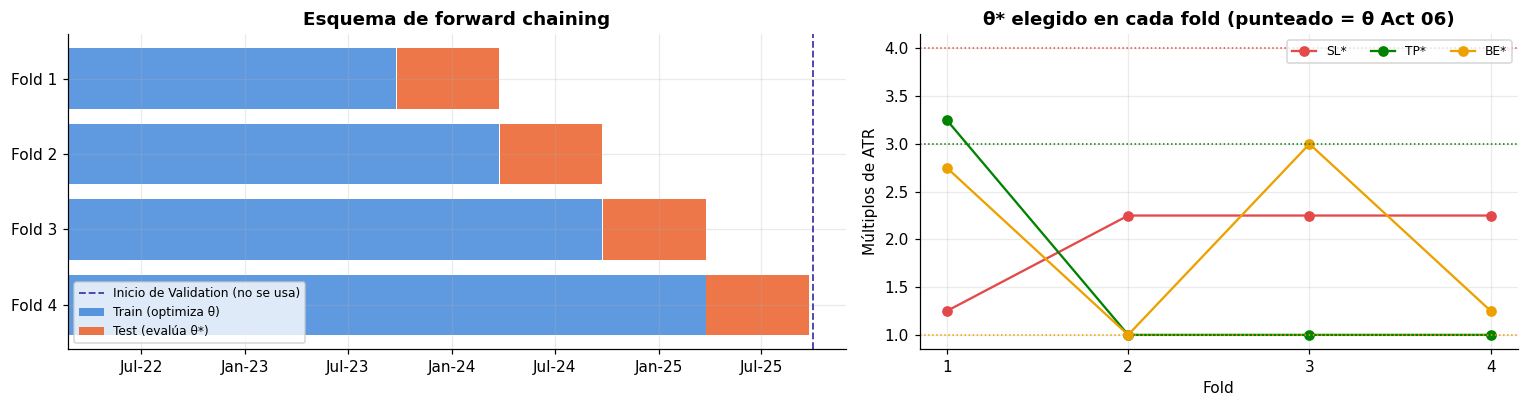

In [28]:
TRAIN_MIN, TEST_LEN, N_TRIALS_WF = 400, 125, 150
folds = forward_chaining_folds(b, WARM, TRAIN_MIN, TEST_LEN)
wf = walk_forward(data.iloc[:b], WARM, TRAIN_MIN, TEST_LEN, n_trials=N_TRIALS_WF, seed=7, base=P)
tabla_wf = wf["tabla"]
display(tabla_wf)

fig, axs = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
for f in folds:
    k = f["fold"]
    axs[0].barh(k, data.index[f["train"][1] - 1] - data.index[f["train"][0]], left=data.index[f["train"][0]],
                color=BLUE, alpha=0.75, label="Train (optimiza θ)" if k == 1 else None)
    axs[0].barh(k, data.index[f["test"][1] - 1] - data.index[f["test"][0]], left=data.index[f["test"][0]],
                color=ORANGE, alpha=0.9, label="Test (evalúa θ*)" if k == 1 else None)
axs[0].axvline(data.index[b], color=VIOLET, ls="--", lw=1.2, label="Inicio de Validation (no se usa)")
axs[0].set_yticks([f["fold"] for f in folds], [f"Fold {f['fold']}" for f in folds]); axs[0].invert_yaxis()
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
axs[0].set_title("Esquema de forward chaining"); axs[0].legend(loc="lower left", fontsize=8)
x = tabla_wf.index
axs[1].plot(x, tabla_wf["SL*"], marker="o", color=BAD, label="SL*")
axs[1].plot(x, tabla_wf["TP*"], marker="o", color=GOOD, label="TP*")
axs[1].plot(x, tabla_wf["BE*"], marker="o", color=WARN, label="BE*")
for v, colr in [(TH0["sl_atr"], BAD), (TH0["tp_atr"], GOOD), (TH0["be_atr"], WARN)]:
    axs[1].axhline(v, color=colr, ls=":", lw=1)
axs[1].set_xticks(x); axs[1].set_xlabel("Fold"); axs[1].set_ylabel("Múltiplos de ATR")
axs[1].set_title("θ* elegido en cada fold (punteado = θ Act 06)"); axs[1].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

,θ* re-optimizado en cada fold,θ fijo de la Act 06
Rendimiento OOS (%),-0.13,1.13
Drawdown máx OOS (%),-3.48,-0.85
Calmar OOS,-0.02,0.66
Operaciones OOS,4.00,4.00
Folds con rendimiento > 0,2.00,1.00


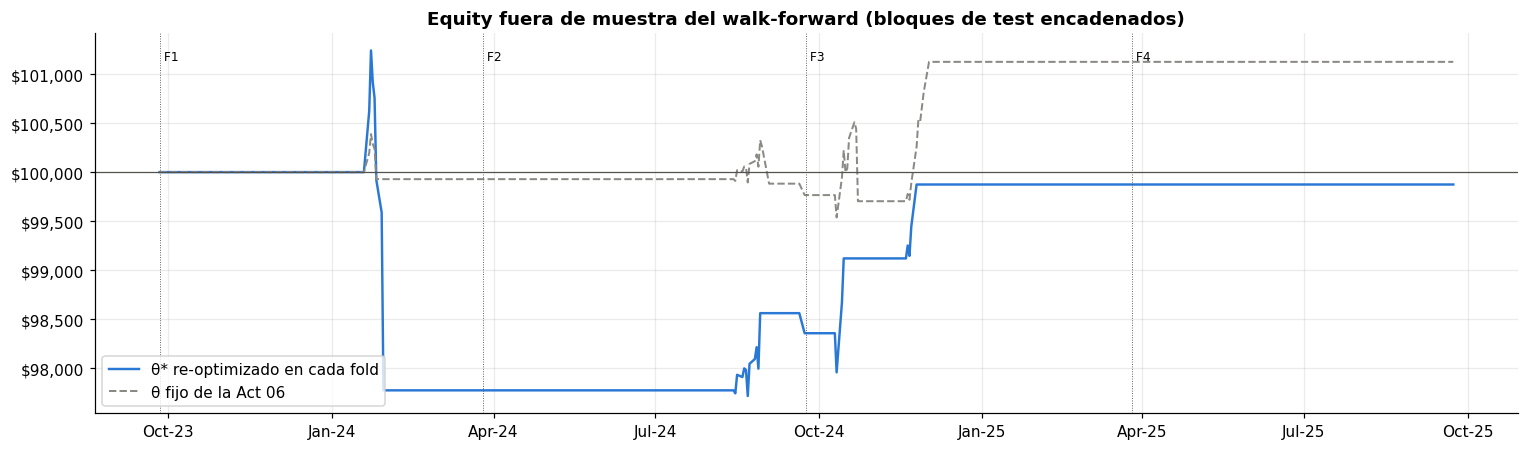

In [29]:
eo, eb = wf["equity_oos_opt"], wf["equity_oos_base"]
res_wf = pd.DataFrame({
    "θ* re-optimizado en cada fold": {"Rendimiento OOS (%)": 100 * (eo.iloc[-1] / P.initial_cash - 1),
                                      "Drawdown máx OOS (%)": 100 * M.max_drawdown(eo), "Calmar OOS": M.calmar(eo),
                                      "Operaciones OOS": tabla_wf["Ops test θ*"].sum(),
                                      "Folds con rendimiento > 0": int((tabla_wf["Rend. test θ* (%)"] > 0).sum())},
    "θ fijo de la Act 06": {"Rendimiento OOS (%)": 100 * (eb.iloc[-1] / P.initial_cash - 1),
                            "Drawdown máx OOS (%)": 100 * M.max_drawdown(eb), "Calmar OOS": M.calmar(eb),
                            "Operaciones OOS": tabla_wf["Ops test θ base"].sum(),
                            "Folds con rendimiento > 0": int((tabla_wf["Rend. test θ base (%)"] > 0).sum())}})
display(res_wf)

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.plot(eo.index, eo, color=BLUE, lw=1.6, label="θ* re-optimizado en cada fold")
ax.plot(eb.index, eb, color=GRAY, lw=1.3, ls="--", label="θ fijo de la Act 06")
for f in folds:
    ax.axvline(data.index[f["test"][0]], color="#52514e", lw=0.6, ls=":")
    ax.text(data.index[f["test"][0]], max(eo.max(), eb.max()), f" F{f['fold']}", va="top", fontsize=8)
ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
ax.set_title("Equity fuera de muestra del walk-forward (bloques de test encadenados)"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 16. Random walk de precios: ¿la ventaja es real o es suerte?

Se generan series de precios **aleatorias** con `random_walk()`: se toman los días reales de AAPL (su gap de apertura, su máximo, su mínimo y su cierre relativos) y se **barajan con reemplazo**. Cada serie tiene los mismos rendimientos diarios, la misma volatilidad y los mismos gaps que AAPL, pero **ninguna tendencia ni momentum real**, porque el orden de los días es aleatorio.

Dos pruebas:

1. **Estrategia fija:** se corre la estrategia con el θ de la Act 06 en 300 random walks y se compara su Calmar contra el de AAPL real.
2. **Optimización sobre ruido:** se corre Optuna en el tramo de train de 40 random walks. El mejor J que se consigue en precios **sin ninguna señal** es la vara de medir: el J\* de AAPL real tiene que superarlo para decir que el optimizador encontró algo más que ruido.

El p-valor es la fracción de random walks que igualan o superan al dato real.

,AAPL real,Random walk: mediana,Random walk: percentil 95,p-valor
Calmar,0.56,0.09,0.85,0.13
Rendimiento total (%),5.12,1.76,9.98,0.25
Operaciones,12.00,13.00,19.00,NaN


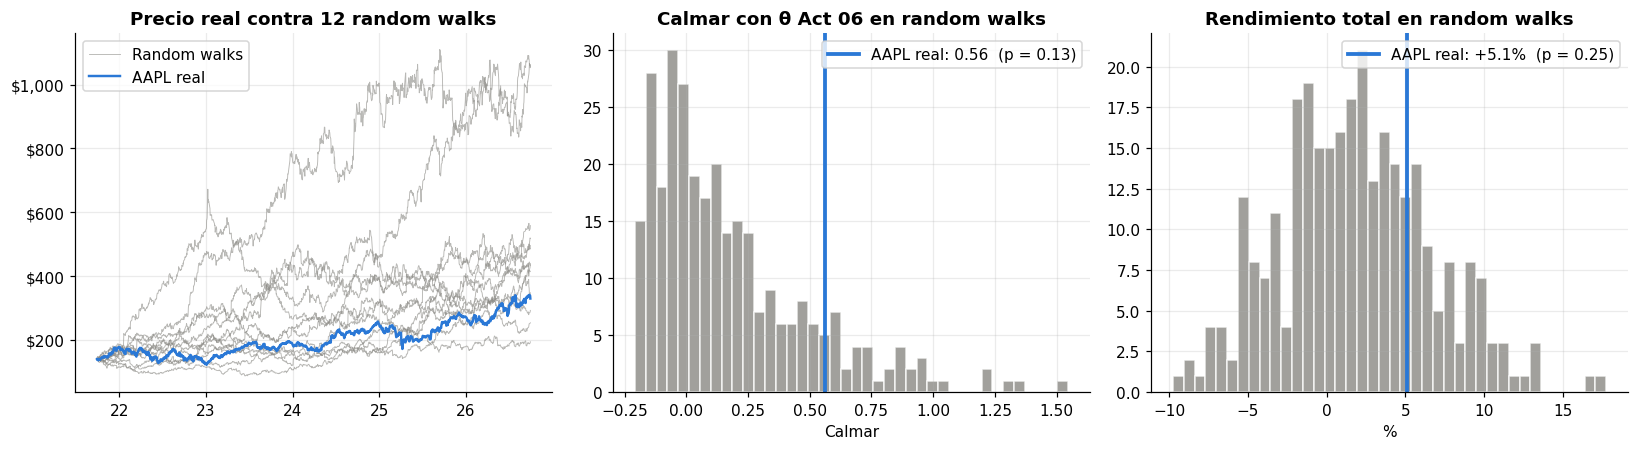

In [30]:
N_RW = 300
sim = []
for s in range(N_RW):
    d_rw = preparar(random_walk(df, seed=s), P)
    r = backtest(d_rw, P); e = r["equity"]["equity"]
    sim.append({"seed": s, "Calmar": M.calmar(e), "Rendimiento (%)": 100 * (e.iloc[-1] / P.initial_cash - 1),
                "Operaciones": len(r["trades"]), "B&H (%)": 100 * (d_rw["close"].iloc[-1] / d_rw["close"].iloc[0] - 1)})
sim = pd.DataFrame(sim)
real_cal, real_ret = resumen["Calmar"], resumen["Rendimiento total (%)"]
p_cal = (sim["Calmar"].fillna(-np.inf) >= real_cal).mean()
p_ret = (sim["Rendimiento (%)"] >= real_ret).mean()

tabla_rw = pd.DataFrame({"AAPL real": [real_cal, real_ret, len(trades)],
                         "Random walk: mediana": [sim["Calmar"].median(), sim["Rendimiento (%)"].median(), sim["Operaciones"].median()],
                         "Random walk: percentil 95": [sim["Calmar"].quantile(.95), sim["Rendimiento (%)"].quantile(.95), sim["Operaciones"].quantile(.95)],
                         "p-valor": [p_cal, p_ret, np.nan]},
                        index=["Calmar", "Rendimiento total (%)", "Operaciones"])
display(tabla_rw)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for s in range(12):
    rw_ = random_walk(df, seed=s)
    axs[0].plot(rw_.index, rw_["close"], color=GRAY, lw=0.6, alpha=0.6, label="Random walks" if s == 0 else None)
axs[0].plot(df.index, df["close"], color=BLUE, lw=1.6, label="AAPL real")
axs[0].set_title("Precio real contra 12 random walks"); axs[0].legend(loc="upper left")
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%y")); axs[0].yaxis.set_major_formatter(usd)
axs[1].hist(sim["Calmar"].dropna().clip(-3, 5), bins=40, color=GRAY, alpha=0.8, edgecolor="white")
axs[1].axvline(real_cal, color=BLUE, lw=2.5, label=f"AAPL real: {real_cal:.2f}  (p = {p_cal:.2f})")
axs[1].set_title("Calmar con θ Act 06 en random walks"); axs[1].set_xlabel("Calmar"); axs[1].legend()
axs[2].hist(sim["Rendimiento (%)"], bins=40, color=GRAY, alpha=0.8, edgecolor="white")
axs[2].axvline(real_ret, color=BLUE, lw=2.5, label=f"AAPL real: {real_ret:+.1f}%  (p = {p_ret:.2f})")
axs[2].set_title("Rendimiento total en random walks"); axs[2].set_xlabel("%"); axs[2].legend()
plt.tight_layout(); plt.show()

In [31]:
N_RW_OPT, N_TRIALS_RW = 40, 80
jstar_rw = []
for s in range(N_RW_OPT):
    d_rw = preparar(random_walk(df, seed=1000 + s), P).iloc[WARM:a]
    _, j_rw, _ = optimizar_optuna(d_rw, n_trials=N_TRIALS_RW, seed=s, base=P)
    jstar_rw.append(j_rw)
jstar_rw = pd.Series(jstar_rw)
jstar_rw_valid = jstar_rw[jstar_rw > PENALTY]
print(f"J* sobre ruido ({N_RW_OPT} random walks, {N_TRIALS_RW} intentos cada uno): "
      f"mediana {jstar_rw_valid.median():.2f}, percentil 95 {jstar_rw_valid.quantile(.95):.2f}")
print(f"Random walks donde ningún θ logró 3 operaciones: {(jstar_rw <= PENALTY).sum()}")

J* sobre ruido (40 random walks, 80 intentos cada uno): mediana 1.44, percentil 95 4.63
Random walks donde ningún θ logró 3 operaciones: 1


## 17. Optimización final con Optuna en Train

$$\theta^* = \arg\max_{\theta}\; \text{Calmar}\big(\text{backtest}(\text{Train},\ \theta)\big)$$

300 intentos de Optuna (TPE), solo con el tramo de Train. Test y Validation no se miran hasta la sección 18.

In [32]:
N_TRIALS = 300
theta_star, J_star, study = optimizar_optuna(tr_data, n_trials=N_TRIALS, seed=42, base=P)
p_snoop = (jstar_rw >= J_star).mean()

comp_theta = pd.DataFrame({"θ Act 06": TH0, "θ* Optuna": theta_star}).T
comp_theta["J(train) = Calmar"] = [objetivo(tr_data, TH0), J_star]
comp_theta["R = TP/SL"] = comp_theta["tp_atr"] / comp_theta["sl_atr"]
comp_theta["p* = 1/(1+R) (%)"] = 100 / (1 + comp_theta["R = TP/SL"])
display(comp_theta)
print(f"J* en AAPL real = {J_star:.2f}  |  J* sobre ruido: mediana {jstar_rw_valid.median():.2f}, "
      f"p95 {jstar_rw_valid.quantile(.95):.2f}  ->  p-valor de data snooping = {p_snoop:.2f}")

trials = study.trials_dataframe(attrs=("number", "value", "params"))
trials.columns = [c.replace("params_", "") for c in trials.columns]
trials_ok = trials[trials["value"] > PENALTY]

,sl_atr,tp_atr,be_atr,J(train) = Calmar,R = TP/SL,p* = 1/(1+R) (%)
θ Act 06,4.00,3.00,1.00,0.18,0.75,57.14
θ* Optuna,2.25,1.00,2.00,1.54,0.44,69.23


J* en AAPL real = 1.54  |  J* sobre ruido: mediana 1.44, p95 4.63  ->  p-valor de data snooping = 0.47


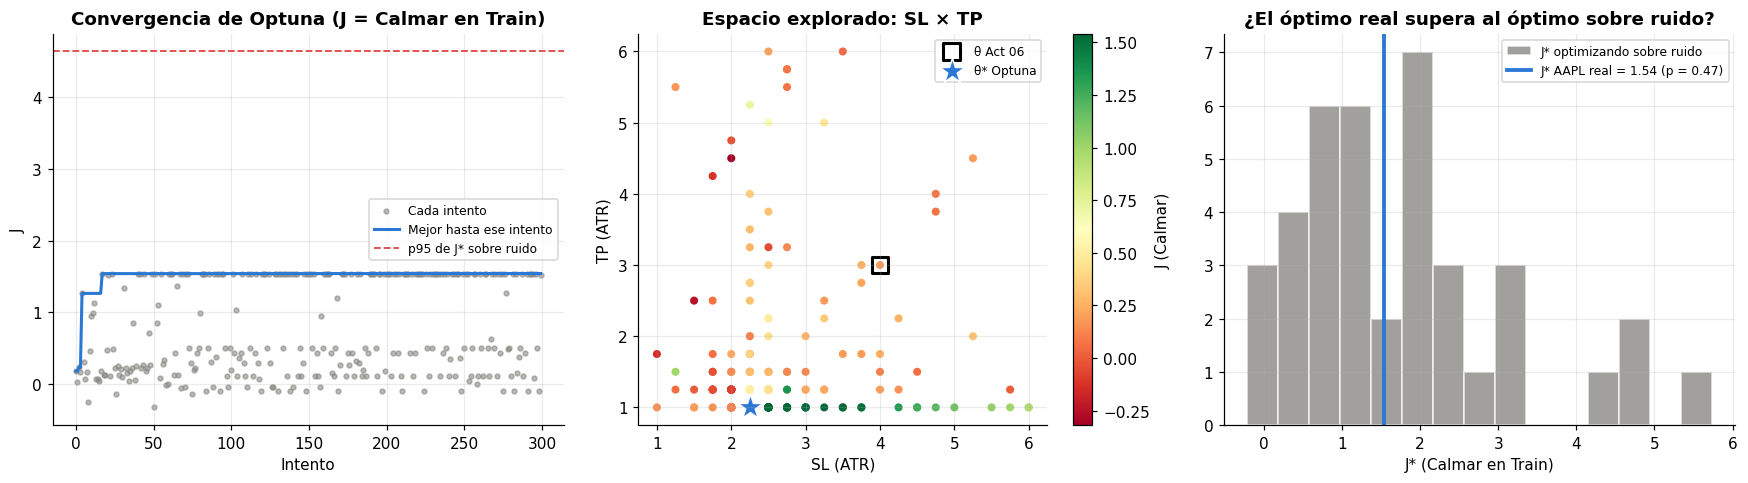

,Importancia relativa
tp_atr,0.39
sl_atr,0.32
be_atr,0.28


In [33]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
axs[0].scatter(trials["number"], trials["value"].clip(lower=-1), s=10, color=GRAY, alpha=0.6, label="Cada intento")
axs[0].plot(trials["number"], trials["value"].cummax(), color=BLUE, lw=2, label="Mejor hasta ese intento")
axs[0].axhline(jstar_rw_valid.quantile(.95), color=BAD, ls="--", lw=1.2, label="p95 de J* sobre ruido")
axs[0].set_title("Convergencia de Optuna (J = Calmar en Train)"); axs[0].set_xlabel("Intento"); axs[0].set_ylabel("J")
axs[0].legend(fontsize=8)
sc = axs[1].scatter(trials_ok["sl_atr"], trials_ok["tp_atr"], c=trials_ok["value"], cmap="RdYlGn", s=28, edgecolor="none")
axs[1].scatter([TH0["sl_atr"]], [TH0["tp_atr"]], marker="s", s=120, facecolors="none", edgecolors="black", lw=2, label="θ Act 06")
axs[1].scatter([theta_star["sl_atr"]], [theta_star["tp_atr"]], marker="*", s=300, color=BLUE, edgecolor="white", label="θ* Optuna")
plt.colorbar(sc, ax=axs[1], label="J (Calmar)")
axs[1].set_xlabel("SL (ATR)"); axs[1].set_ylabel("TP (ATR)"); axs[1].set_title("Espacio explorado: SL × TP"); axs[1].legend(fontsize=8)
axs[2].hist(jstar_rw_valid, bins=15, color=GRAY, alpha=0.8, edgecolor="white", label="J* optimizando sobre ruido")
axs[2].axvline(J_star, color=BLUE, lw=2.5, label=f"J* AAPL real = {J_star:.2f} (p = {p_snoop:.2f})")
axs[2].set_title("¿El óptimo real supera al óptimo sobre ruido?"); axs[2].set_xlabel("J* (Calmar en Train)"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

try:
    imp = optuna.importance.get_param_importances(study)
    display(pd.Series(imp, name="Importancia relativa").to_frame())
except Exception as err:
    print("No se pudo calcular la importancia de parámetros:", err)

## 18. Evaluación fuera de muestra: θ\* contra θ de la Act 06

Se corren los dos θ en los tres tramos. Train es **dentro de muestra** para θ\* (ahí se eligió), así que ahí siempre va a ganar; la comparación que importa es **Test y Validation**.

,Train,Test,Validation,Train,Test,Validation
,θ Act 06,θ Act 06,θ Act 06,θ* Optuna,θ* Optuna,θ* Optuna
Rendimiento total (%),0.86,1.36,2.86,6.72,1.54,2.40
Rendimiento anualizado CAGR (%),0.33,1.36,2.87,2.54,1.54,2.40
Drawdown máximo (%),-1.79,-0.80,-1.24,-1.65,-0.41,-0.20
Calmar,0.18,1.69,2.32,1.54,3.78,11.87
Sharpe (anualizado),0.25,1.13,1.78,1.11,1.41,2.29
Operaciones cerradas,6,2,3,8,2,3
Win rate empírico (%),16.67,50.00,66.67,100.00,100.00,100.00
Expectancy (R por operación),0.07,0.34,0.47,0.41,0.38,0.40
Veredicto (Calmar),NO VIABLE,VIABLE,VIABLE,VIABLE,VIABLE,VIABLE


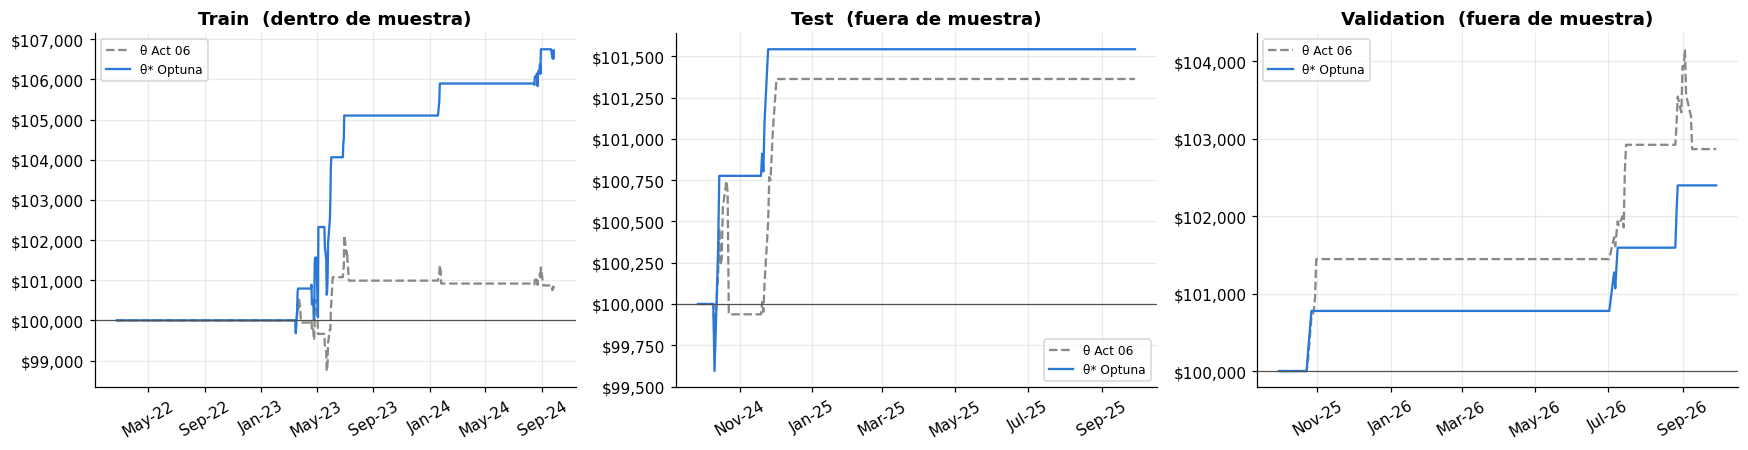

In [34]:
filas = {}
for nombre, th in [("θ Act 06", TH0), ("θ* Optuna", theta_star)]:
    for tramo, d_ in [("Train", tr_data), ("Test", te_data), ("Validation", va_data)]:
        s_ = M.summary(backtest(d_, theta_to_params(th, P)))
        filas[(tramo, nombre)] = s_[["Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
                                     "Calmar", "Sharpe (anualizado)", "Operaciones cerradas", "Win rate empírico (%)",
                                     "Expectancy (R por operación)", "Veredicto (Calmar)"]]
eval_oos = pd.DataFrame(filas)
display(eval_oos)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, (tramo, d_) in zip(axs, [("Train", tr_data), ("Test", te_data), ("Validation", va_data)]):
    for nombre, th, colr, ls in [("θ Act 06", TH0, GRAY, "--"), ("θ* Optuna", theta_star, BLUE, "-")]:
        e_ = backtest(d_, theta_to_params(th, P))["equity"]["equity"]
        ax.plot(e_.index, e_, color=colr, ls=ls, lw=1.5, label=nombre)
    ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y")); ax.tick_params(axis="x", labelrotation=30)
    ax.set_title(f"{tramo}" + ("  (dentro de muestra)" if tramo == "Train" else "  (fuera de muestra)")); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 18.1 ¿Lo que es bueno en Train sigue siendo bueno en Test?
Si la optimización encuentra algo real, los θ con mejor J en Train deberían tender a tener mejor J en Test. Se toman todos los intentos de Optuna con al menos 3 operaciones en Train y se evalúan en Test (si un θ no opera en Test, su J es 0: ni gana ni pierde). Una correlación de rangos (Spearman) cercana a cero o negativa indica **overfitting**: el orden de Train no se conserva fuera de muestra.

Intentos comparados: 300  |  correlación de Spearman J(train) vs J(test) = -0.44
J(test) promedio del top 10 de Train: 1.54  |  J(test) promedio de todos: 1.68


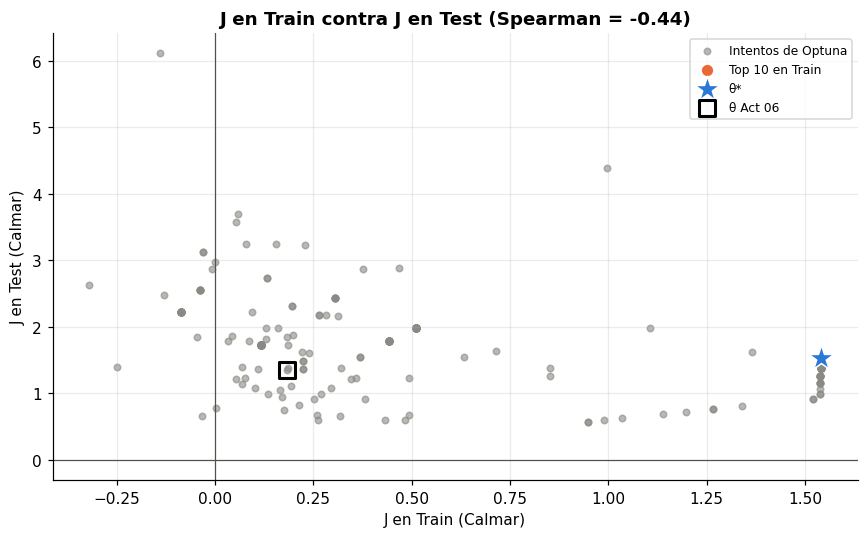

In [35]:
j_test = [objetivo(te_data, {"sl_atr": r_.sl_atr, "tp_atr": r_.tp_atr, "be_atr": r_.be_atr}, P, min_trades=0)
          for r_ in trials_ok.itertuples()]
tt = trials_ok.assign(J_test=j_test)
rho_s = tt["value"].corr(tt["J_test"], method="spearman") if tt["J_test"].nunique() > 1 else np.nan
if np.isnan(rho_s):
    print("No se puede calcular la correlación: en Test todos los θ dan el mismo J (casi no hay operaciones).")
top = tt.nlargest(10, "value")
print(f"Intentos comparados: {len(tt)}  |  correlación de Spearman J(train) vs J(test) = {rho_s:+.2f}")
print(f"J(test) promedio del top 10 de Train: {top['J_test'].mean():.2f}  |  J(test) promedio de todos: {tt['J_test'].mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tt["value"], tt["J_test"], s=18, color=GRAY, alpha=0.6, label="Intentos de Optuna")
ax.scatter(top["value"], top["J_test"], s=40, color=ORANGE, label="Top 10 en Train")
ax.scatter([J_star], [objetivo(te_data, theta_star, P, min_trades=0)], marker="*", s=300, color=BLUE, edgecolor="white", label="θ*")
ax.scatter([objetivo(tr_data, TH0, P)], [objetivo(te_data, TH0, P, min_trades=0)], marker="s", s=110,
           facecolors="none", edgecolors="black", lw=2, label="θ Act 06")
ax.axhline(0, color="#52514e", lw=0.8); ax.axvline(0, color="#52514e", lw=0.8)
ax.set_xlabel("J en Train (Calmar)"); ax.set_ylabel("J en Test (Calmar)")
ax.set_title(f"J en Train contra J en Test (Spearman = {rho_s:+.2f})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [36]:
resumen_opt = pd.DataFrame({"Valor": {
    "θ* (SL, TP, BE)": f"({theta_star['sl_atr']}, {theta_star['tp_atr']}, {theta_star['be_atr']})",
    "J* en Train": round(J_star, 2),
    "p-valor contra optimizar ruido": round(p_snoop, 2),
    "p-valor θ Act 06 contra random walks (Calmar)": round(p_cal, 2),
    "Walk-forward: rendimiento OOS θ* (%)": round(res_wf.loc["Rendimiento OOS (%)", "θ* re-optimizado en cada fold"], 2),
    "Walk-forward: rendimiento OOS θ Act 06 (%)": round(res_wf.loc["Rendimiento OOS (%)", "θ fijo de la Act 06"], 2),
    "Calmar Test: θ* / θ Act 06": f"{eval_oos[('Test', 'θ* Optuna')]['Calmar']:.2f} / {eval_oos[('Test', 'θ Act 06')]['Calmar']:.2f}",
    "Calmar Validation: θ* / θ Act 06": f"{eval_oos[('Validation', 'θ* Optuna')]['Calmar']:.2f} / {eval_oos[('Validation', 'θ Act 06')]['Calmar']:.2f}",
    "Spearman J(train) vs J(test)": round(rho_s, 2),
}})
resumen_opt

,Valor
"θ* (SL, TP, BE)","(2.25, 1.0, 2.0)"
J* en Train,1.54
p-valor contra optimizar ruido,0.48
p-valor θ Act 06 contra random walks (Calmar),0.13
Walk-forward: rendimiento OOS θ* (%),-0.13
Walk-forward: rendimiento OOS θ Act 06 (%),1.13
Calmar Test: θ* / θ Act 06,3.78 / 1.69
Calmar Validation: θ* / θ Act 06,11.87 / 2.32
Spearman J(train) vs J(test),-0.44


## 19. Conclusión de la optimización

*(Se completa con los resultados de AAPL.)*

# Parte 3: Act 07 — Regímenes de mercado

## 20. Planteamiento

Hasta ahora la estrategia usa **un solo θ** para todo el periodo. La idea de esta parte es que el mercado no siempre se comporta igual: hay momentos de **Crisis** (mucha volatilidad), de **Tendencia** y de **Mean reverting** (el precio va y viene). Si se puede reconocer en qué régimen está el mercado, se puede usar un θ distinto en cada uno.

| # | Punto de la Act 07 | Sección |
|---|---|---|
| 1 | Implementar `regime_features()` y correr la prueba de truncamiento en cada columna | 21 |
| – | Regla del codo para el número de clusters | 22 |
| 2 | Ajustar los tres clasificadores (reglas, K-means, HMM) en el tramo de entrenamiento | 23 |
| 3 | Tabla comparativa: silhouette, duración media, transiciones por mes y participación | 24 |
| 4 | Línea de tiempo del precio coloreada por la etiqueta **filtrada**, con Viterbi al lado | 25 |
| 5 | Distribución de las features por régimen y justificación de los nombres con los centroides | 26 |
| 6 | Elegir un método y defenderlo | 27 |
| 7 | Operar los regímenes: un θ por estado contra el θ\* único, en Train y Test | 28 |

**Matriz de features** (una fila por día, tres columnas):

| Feature | Fórmula | Qué mide |
|---|---|---|
| `vol` | σ = desviación estándar de los rendimientos log de los últimos 20 días | Nivel de volatilidad → **Crisis** |
| `trend` | (SMA_10 − SMA_100) / (close × σ) | Fuerza de tendencia: distancia entre las medias medida en "días de volatilidad" → **Tendencia** |
| `ac1` | Autocorrelación lag 1 de los rendimientos en los últimos 60 días | Si es negativa, lo que sube hoy tiende a bajar mañana → **Mean reverting** |

> En `trend` la diferencia de medias está en dólares y σ es un porcentaje, así que se multiplica σ por el precio para que las unidades cuadren (dólares entre dólares). El resultado no tiene unidades y es comparable entre fechas con precios muy distintos.

**Dos tipos de etiqueta**

* **Filtrada:** la que se puede conocer el día *t* usando solo datos hasta *t*. Es la única que se puede operar.
* **Viterbi (solo HMM):** la secuencia de estados más probable usando **toda** la serie. Mira al futuro, así que se ve más limpia, pero no se puede operar. Se muestra al lado para ver cuánto se pierde por no conocer el futuro.

Todo se **ajusta solo con Train** (umbrales, media y desviación para estandarizar, centroides y parámetros del HMM) y después se aplica sin cambios a Test y Validation.

In [37]:
from src.regimes import (FEATURES, REGIMENES, regime_features, fit_scaler, fit_rules, predict_rules,
                         elbow, elbow_point, fit_kmeans, predict_kmeans, fit_hmm, predict_hmm, hmm_filter,
                         regime_stats, backtest_regimes, gate_by_regime, optimize_by_regime, params_from_table)

COL_REG = {"Crisis": BAD, "Tendencia": GOOD, "Mean reverting": BLUE}
VOL_WIN, SMA_FAST, SMA_SLOW, AC_WIN = 20, 10, 100, 60

## 21. Matriz de features y prueba de truncamiento por columna

In [38]:
feats = regime_features(df, VOL_WIN, SMA_FAST, SMA_SLOW, AC_WIN)
print(f"Matriz de features: {feats.shape[0]} filas x {feats.shape[1]} columnas  |  primera fila completa: "
      f"{feats.dropna().index[0]:%Y-%m-%d} (barra {feats.index.get_loc(feats.dropna().index[0])})")
with pd.option_context("display.float_format", lambda x: f"{x:,.4f}"):
    display(feats.dropna().head())
    display(feats.iloc[WARM:a].describe().T.rename_axis("Feature (Train)"))

Matriz de features: 1255 filas x 3 columnas  |  primera fila completa: 2022-02-18 (barra 99)


,vol,trend,ac1
Date,,,
2022-02-18,0.0207,2.7630,0.1272
2022-02-22,0.0211,2.4833,0.1343
2022-02-23,0.0218,1.9910,0.1611
2022-02-24,0.0221,1.4988,0.1754
2022-02-25,0.0223,1.2016,0.1579


,count,mean,std,min,25%,50%,75%,max
Feature (Train),,,,,,,,
vol,653.0000,0.0165,0.0059,0.0071,0.0122,0.0155,0.0199,0.0342
trend,653.0000,1.7817,5.1861,-7.3907,-2.3998,1.2016,5.9544,12.9969
ac1,653.0000,0.0275,0.1084,-0.1844,-0.0565,0.0146,0.1011,0.3034


In [39]:
# Prueba de truncamiento: se recalcula con df.iloc[:t+1] y el valor en t no debe cambiar
filas = []
for t in [300, 700, 1100]:
    part = regime_features(df.iloc[:t + 1], VOL_WIN, SMA_FAST, SMA_SLOW, AC_WIN)
    for col in FEATURES:
        filas.append({"t": t, "fecha": df.index[t], "columna": col, "completo": feats[col].iloc[t],
                      "truncado": part[col].iloc[-1], "|diferencia|": abs(feats[col].iloc[t] - part[col].iloc[-1])})
trunc_feats = pd.DataFrame(filas)
with pd.option_context("display.float_format", lambda x: f"{x:,.6f}"):
    display(trunc_feats)

ts7 = np.linspace(WARM + 1, len(df) - 1, 60).astype(int)
max_dif = max(np.nanmax(np.abs(regime_features(df.iloc[:t + 1], VOL_WIN, SMA_FAST, SMA_SLOW, AC_WIN).iloc[-1].to_numpy()
                               - feats.iloc[t].to_numpy())) for t in ts7)
print(f"Barrido de {len(ts7)} fechas x 3 columnas: diferencia máxima = {max_dif:.1e}")

,t,fecha,columna,completo,truncado,|diferencia|
0,300,2022-12-07,vol,0.027826,0.027826,0.000000
1,300,2022-12-07,trend,-1.698447,-1.698447,0.000000
2,300,2022-12-07,ac1,-0.046768,-0.046768,0.000000
3,700,2024-07-15,vol,0.015264,0.015264,0.000000
4,700,2024-07-15,trend,11.005408,11.005408,0.000000
5,700,2024-07-15,ac1,-0.060355,-0.060355,0.000000
6,1100,2026-02-18,vol,0.019899,0.019899,0.000000
7,1100,2026-02-18,trend,0.815650,0.815650,0.000000
8,1100,2026-02-18,ac1,0.125382,0.125382,0.000000


Barrido de 60 fechas x 3 columnas: diferencia máxima = 0.0e+00


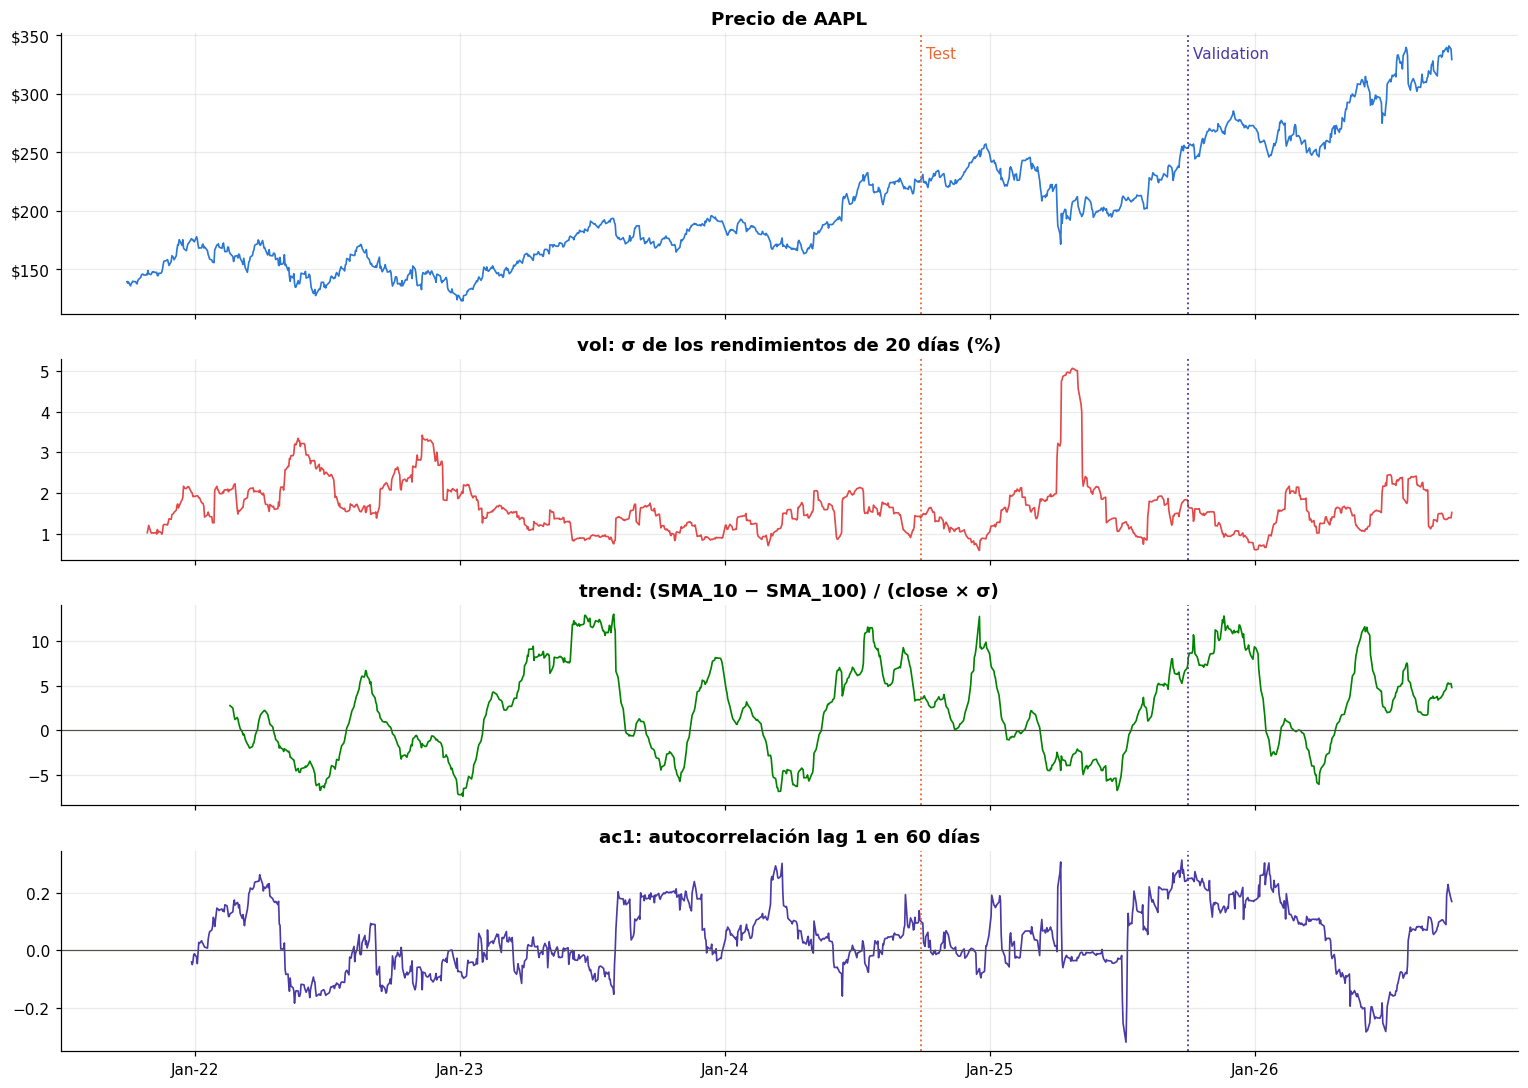

In [40]:
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [1.4, 1, 1, 1]})
axs[0].plot(df.index, df["close"], color=BLUE, lw=1.1); axs[0].set_title("Precio de AAPL"); axs[0].yaxis.set_major_formatter(usd)
axs[1].plot(feats.index, 100 * feats["vol"], color=BAD, lw=1.1)
axs[1].set_title(f"vol: σ de los rendimientos de {VOL_WIN} días (%)")
axs[2].plot(feats.index, feats["trend"], color=GOOD, lw=1.1); axs[2].axhline(0, color="#52514e", lw=0.8)
axs[2].set_title(f"trend: (SMA_{SMA_FAST} − SMA_{SMA_SLOW}) / (close × σ)")
axs[3].plot(feats.index, feats["ac1"], color=VIOLET, lw=1.1); axs[3].axhline(0, color="#52514e", lw=0.8)
axs[3].set_title(f"ac1: autocorrelación lag 1 en {AC_WIN} días")
for ax in axs:
    ax.axvline(df.index[a], color=ORANGE, ls=":", lw=1.2); ax.axvline(df.index[b], color=VIOLET, ls=":", lw=1.2)
axs[0].text(df.index[a], df["close"].max(), " Test", color=ORANGE, va="top")
axs[0].text(df.index[b], df["close"].max(), " Validation", color=VIOLET, va="top")
axs[3].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()

### 21.1 Estandarización con Train
K-means y el HMM trabajan con distancias, así que las tres features tienen que estar en la misma escala. Se estandarizan con la **media y la desviación de Train** (z = (x − media_train) / desv_train). No se recalculan con Test ni Validation: eso sería usar información del futuro.

In [41]:
feats_tr = feats.iloc[WARM:a]
scaler = fit_scaler(feats_tr)
Z = scaler.transform(feats)                 # toda la serie, con la escala de train
Z_tr = Z.iloc[WARM:a]
display(pd.DataFrame({"Media de train": scaler.mean, "Desviación de train": scaler.std}).style.format("{:.4f}"))
print("Correlación entre features (Train):"); display(Z_tr.corr())

,Media de train,Desviación de train
vol,0.0165,0.0059
trend,1.7817,5.1821
ac1,0.0275,0.1083


Correlación entre features (Train):


,vol,trend,ac1
vol,1.00,-0.50,-0.44
trend,-0.50,1.00,-0.12
ac1,-0.44,-0.12,1.00


## 22. Regla del codo

Antes de fijar el número de clusters se corre K-means para k = 1…8 sobre las features estandarizadas de Train y se grafica la **inercia** (suma de distancias al cuadrado de cada punto a su centroide). La inercia siempre baja al aumentar k; el "codo" es el punto donde agregar otro cluster ya casi no ayuda.

Se marcan dos cosas: el **codo geométrico** (el punto más alejado de la recta que une el primer y el último valor) y **k = 3**, que es el número que se usa porque se quieren tres regímenes con nombre (Crisis, Tendencia y Mean reverting). También se reporta el silhouette de cada k.

c:\Users\Isabela\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Isabela\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Isabela\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, t

,Inercia,Silhouette,Caída de inercia (%)
k,,,
1,"1,959.00",NaN,NaN
2,"1,163.87",0.42,40.59
3,648.56,0.44,44.28
4,509.49,0.38,21.44
5,420.57,0.37,17.45
6,363.89,0.36,13.48
7,323.56,0.36,11.08
8,288.72,0.35,10.77


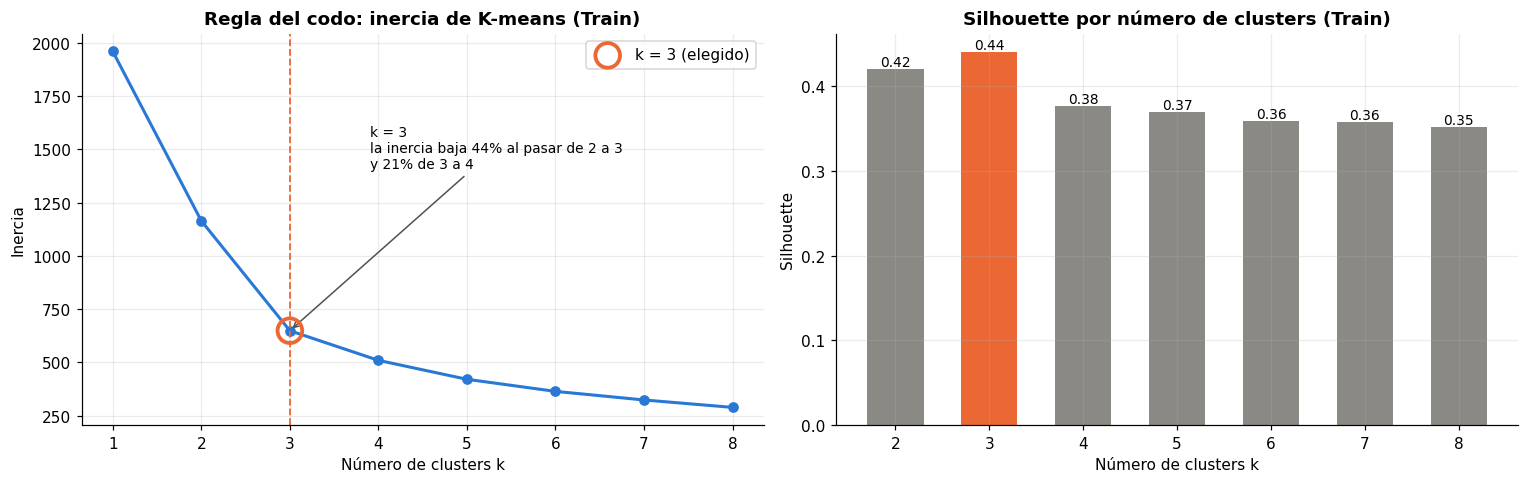

Codo geométrico: k = 3.  Se usa k = 3.  Coinciden.
Silhouette con k = 3: 0.440  |  mejor silhouette: k = 3 (0.440)


In [42]:
codo = elbow(Z_tr, k_max=8, seed=42)
k_codo = elbow_point(codo["Inercia"])
K = 3
display(codo)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].plot(codo.index, codo["Inercia"], color=BLUE, lw=2, marker="o")
axs[0].scatter([K], [codo.loc[K, "Inercia"]], s=260, facecolors="none", edgecolors=ORANGE, lw=2.5, zorder=5, label=f"k = {K} (elegido)")
axs[0].axvline(K, color=ORANGE, ls="--", lw=1.2)
if k_codo != K:
    axs[0].axvline(k_codo, color=GRAY, ls=":", lw=1.2, label=f"Codo geométrico: k = {k_codo}")
axs[0].annotate(f"k = {K}\nla inercia baja {codo.loc[K, 'Caída de inercia (%)']:.0f}% al pasar de {K-1} a {K}\ny {codo.loc[K+1, 'Caída de inercia (%)']:.0f}% de {K} a {K+1}",
                xy=(K, codo.loc[K, "Inercia"]), xytext=(K + 0.9, codo["Inercia"].iloc[0] * 0.72),
                arrowprops=dict(arrowstyle="->", color="#52514e"), fontsize=9)
axs[0].set_title("Regla del codo: inercia de K-means (Train)"); axs[0].set_xlabel("Número de clusters k"); axs[0].set_ylabel("Inercia")
axs[0].legend(loc="upper right")
axs[1].bar(codo.index[1:], codo["Silhouette"].iloc[1:], color=[ORANGE if k == K else GRAY for k in codo.index[1:]], width=0.6)
for k, v in codo["Silhouette"].iloc[1:].items(): axs[1].text(k, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
axs[1].set_title("Silhouette por número de clusters (Train)"); axs[1].set_xlabel("Número de clusters k"); axs[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

print(f"Codo geométrico: k = {k_codo}.  Se usa k = {K}." +
      ("  Coinciden." if k_codo == K else f"  No coinciden: k = {K} se mantiene porque se quieren tres regímenes con interpretación económica."))
print(f"Silhouette con k = {K}: {codo.loc[K, 'Silhouette']:.3f}  |  mejor silhouette: k = {codo['Silhouette'].idxmax()} ({codo['Silhouette'].max():.3f})")

## 23. Los tres clasificadores, ajustados en Train

### 23.1 Reglas
Las reglas se aplican **en orden de prioridad**, así cada día recibe exactamente una etiqueta. Los umbrales son cuantiles de Train:

| Prioridad | Régimen | Regla | Idea |
|---|---|---|---|
| 1 | **Crisis** | `vol` > percentil 80 de `vol` | Si la volatilidad está en el 20 % más alto, es crisis sin importar lo demás. |
| 2 | **Tendencia** | no es crisis **y** \|`trend`\| ≥ mediana de \|`trend`\| **y** `ac1` > percentil 25 de `ac1` | Las medias están bien separadas y los rendimientos no se están revirtiendo con fuerza. |
| 3 | **Mean reverting** | todo lo demás | Volatilidad normal con tendencia débil, o con autocorrelación muy negativa (el precio va y viene). |

In [43]:
reglas = fit_rules(feats_tr)
display(pd.DataFrame({"Umbral (Train)": {
    f"vol_alta = percentil {100*reglas['q_vol']:.0f} de vol": reglas["vol_alta"],
    f"trend_fuerte = percentil {100*reglas['q_trend']:.0f} de |trend|": reglas["trend_fuerte"],
    f"ac_baja = percentil {100*reglas['q_ac']:.0f} de ac1": reglas["ac_baja"]}}).style.format("{:.4f}"))
lab_reglas = predict_rules(feats, reglas)

,Umbral (Train)
vol_alta = percentil 80 de vol,0.0209
trend_fuerte = percentil 50 de |trend|,3.9298
ac_baja = percentil 25 de ac1,-0.0565


### 23.2 K-means (k = 3)
K-means agrupa los días de Train en 3 clusters según su distancia en el espacio (vol, trend, ac1) estandarizado. El algoritmo no sabe qué es cada cluster: los **nombres se asignan con los centroides** (el de mayor volatilidad es Crisis; de los otros dos, el de mayor \|trend\| es Tendencia; el que queda es Mean reverting). Para un día nuevo, la etiqueta es el centroide más cercano, así que es causal.

In [44]:
km = fit_kmeans(Z_tr, k=K, seed=42)
lab_km = predict_kmeans(Z, km)
cent_km = km["centers"].rename(index=km["names"]).reindex(REGIMENES)
print("Centroides de K-means (en desviaciones estándar de Train):"); display(cent_km)

c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Centroides de K-means (en desviaciones estándar de Train):


,vol,trend,ac1
Crisis,1.39,-0.92,-1.09
Tendencia,-0.50,0.93,-0.26
Mean reverting,-0.32,-0.57,1.12


### 23.3 HMM (cadena de Markov oculta)
El HMM supone que el mercado está en uno de 3 estados ocultos, que cada estado genera las features con una distribución normal distinta, y que el estado de mañana depende del de hoy según una **matriz de transición**. A diferencia de K-means, toma en cuenta el **tiempo**: si hoy es crisis, lo más probable es que mañana también.

* Etiqueta **filtrada**: argmax de P(estado_t | features hasta t), calculada con el algoritmo *forward*.
* Etiqueta **Viterbi**: la secuencia más probable usando toda la serie (no se puede operar).

In [46]:
%pip install hmmlearn

   ---------------------------------------- 0.0/127.3 kB ? eta -:--:--
   --- ------------------------------------ 10.2/127.3 kB ? eta -:--:--
   ---------------------------- ----------- 92.2/127.3 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 127.3/127.3 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [47]:
hmm = fit_hmm(Z_tr, k=K, seed=42)
lab_hmm = predict_hmm(Z, hmm)
orden = [k for r in REGIMENES for k, v in hmm["names"].items() if v == r]
cent_hmm = hmm["centers"].rename(index=hmm["names"]).reindex(REGIMENES)
print("Medias de cada estado del HMM (en desviaciones estándar de Train):"); display(cent_hmm)
trans = pd.DataFrame(hmm["model"].transmat_[np.ix_(orden, orden)], index=[f"de {r}" for r in REGIMENES], columns=[f"a {r}" for r in REGIMENES])
print("Matriz de transición (probabilidad de pasar de un estado a otro en un día):"); display(trans.style.format("{:.3f}"))
dur_teo = pd.Series(1 / np.maximum(1 - np.diag(trans.to_numpy()), 1e-6), index=REGIMENES, name="Duración esperada (días) = 1 / (1 − p_ii)")
display(dur_teo.to_frame())

# Comprobación de que la etiqueta filtrada es causal: se trunca la serie y la etiqueta en t no cambia
ok_ = Z[FEATURES].notna().all(axis=1)
X_all = Z.loc[ok_, FEATURES].to_numpy(); full_f = hmm_filter(hmm["model"], X_all)
dif_f = max(np.abs(hmm_filter(hmm["model"], X_all[:t + 1])[-1] - full_f[t]).max() for t in [200, 500, 900, len(X_all) - 1])
print(f"Etiqueta filtrada del HMM, prueba de truncamiento: diferencia máxima de probabilidad = {dif_f:.1e}")

c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Isabela\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak o

Medias de cada estado del HMM (en desviaciones estándar de Train):


,vol,trend,ac1
Crisis,1.15,-0.92,-0.92
Tendencia,-0.49,0.89,-0.20
Mean reverting,-0.38,-0.58,1.36


Matriz de transición (probabilidad de pasar de un estado a otro en un día):


,a Crisis,a Tendencia,a Mean reverting
de Crisis,0.984,0.016,0.000
de Tendencia,0.003,0.990,0.007
de Mean reverting,0.012,0.006,0.982


,Duración esperada (días) = 1 / (1 − p_ii)
Crisis,61.24
Tendencia,98.06
Mean reverting,56.46


Etiqueta filtrada del HMM, prueba de truncamiento: diferencia máxima de probabilidad = 6.4e-22


### 23.4 Columnas de etiqueta en el dataset
Se agregan al dataset las tres features y una columna de etiqueta por método (más la de Viterbi como referencia).

In [48]:
data = data.drop(columns=[c for c in data.columns if c in FEATURES or c.startswith("etiqueta")], errors="ignore")
data = data.join(feats)
data["etiqueta_reglas"] = lab_reglas
data["etiqueta_kmeans"] = lab_km
data["etiqueta_hmm"] = lab_hmm["filtrada"]
data["etiqueta_hmm_viterbi"] = lab_hmm["viterbi"]
METODOS = {"Reglas": "etiqueta_reglas", "K-means": "etiqueta_kmeans", "HMM (filtrada)": "etiqueta_hmm"}
display(data[["close", "vol", "trend", "ac1", "etiqueta_reglas", "etiqueta_kmeans", "etiqueta_hmm", "etiqueta_hmm_viterbi"]].iloc[WARM:].tail(8))

,close,vol,trend,ac1,etiqueta_reglas,etiqueta_kmeans,etiqueta_hmm,etiqueta_hmm_viterbi
Date,,,,,,,,
2026-09-18,336.13,0.01,4.29,0.10,Tendencia,Tendencia,Tendencia,Tendencia
2026-09-21,338.98,0.01,4.57,0.09,Tendencia,Tendencia,Tendencia,Tendencia
2026-09-22,339.75,0.01,4.92,0.19,Tendencia,Mean reverting,Tendencia,Mean reverting
2026-09-23,337.02,0.01,5.20,0.21,Tendencia,Mean reverting,Mean reverting,Mean reverting
2026-09-24,335.92,0.01,5.30,0.23,Tendencia,Mean reverting,Mean reverting,Mean reverting
2026-09-25,341.07,0.01,5.18,0.21,Tendencia,Mean reverting,Mean reverting,Mean reverting
2026-09-28,338.40,0.01,5.24,0.18,Tendencia,Mean reverting,Mean reverting,Mean reverting
2026-09-29,329.40,0.02,4.79,0.17,Tendencia,Mean reverting,Mean reverting,Mean reverting


## 24. Tabla comparativa de los tres métodos

| Métrica | Qué mide | Qué se busca |
|---|---|---|
| **Silhouette** | Qué tan separados están los regímenes en el espacio de features (−1 a 1) | Alto |
| **Duración media** | Cuántos días seguidos dura un régimen en promedio | Alta: un régimen que cambia cada dos días no se puede operar |
| **Transiciones por mes** | Cuántas veces cambia la etiqueta en 21 días | Baja |
| **Participación** | Porcentaje de días en cada régimen | Que ninguno quede casi vacío |

Se calcula en Train (donde se ajustó) y en Test (fuera de muestra). Viterbi se incluye solo como referencia.

TRAIN


,Silhouette,Duración media (barras),Transiciones por mes,% Crisis,% Tendencia,% Mean reverting
Reglas,0.15,12.09,1.70,20.06,36.14,43.80
K-means,0.44,31.10,0.64,23.43,43.34,33.23
HMM (filtrada),0.43,65.30,0.29,28.79,45.33,25.88
"HMM (Viterbi, referencia)",0.43,65.30,0.29,28.02,45.94,26.03


TEST (fuera de muestra)


,Silhouette,Duración media (barras),Transiciones por mes,% Crisis,% Tendencia,% Mean reverting
Reglas,0.17,13.21,1.51,15.94,29.88,54.18
K-means,0.20,8.37,2.43,24.70,32.27,43.03
HMM (filtrada),0.22,25.10,0.75,37.45,37.45,25.10
"HMM (Viterbi, referencia)",0.23,25.10,0.75,37.85,35.06,27.09


Porcentaje de días en que dos métodos dan la misma etiqueta:


,Reglas,K-means,HMM (filtrada)
Reglas,100.00,58.01,50.74
K-means,58.01,100.00,85.37
HMM (filtrada),50.74,85.37,100.00


HMM: la etiqueta filtrada coincide con Viterbi en 96.6% de los días.


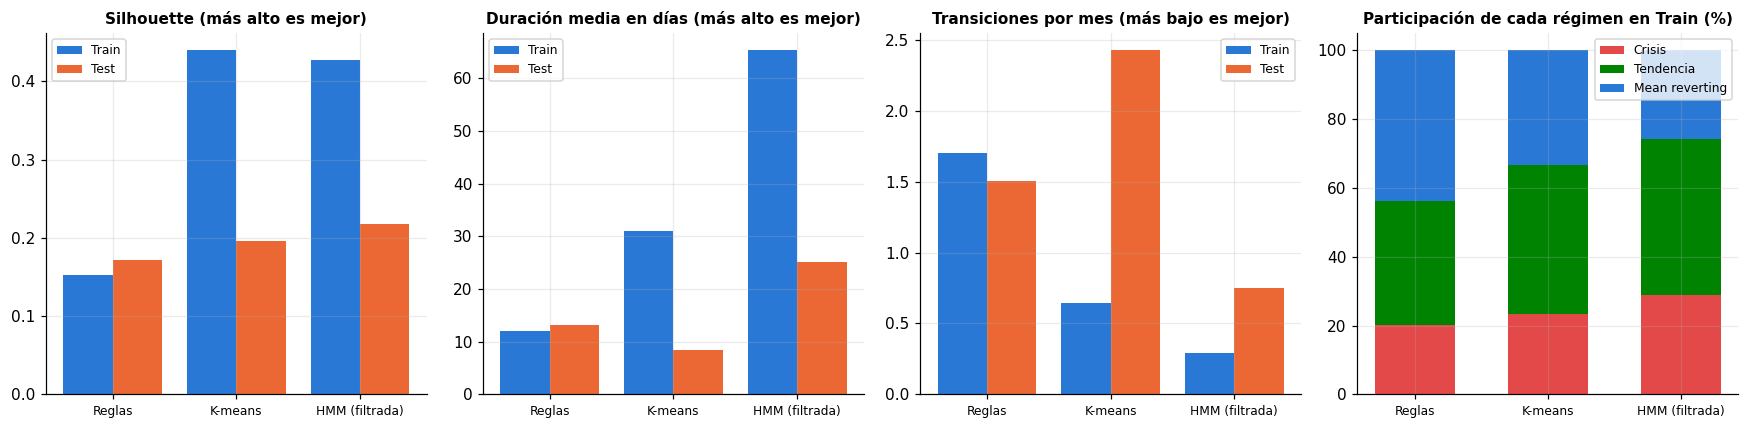

In [49]:
def tabla_stats(sl):
    cols = {**METODOS, "HMM (Viterbi, referencia)": "etiqueta_hmm_viterbi"}
    t_ = pd.DataFrame({n: regime_stats(data[c].iloc[sl], Z.iloc[sl]) for n, c in cols.items()}).T
    return t_[["Silhouette", "Duración media (barras)", "Transiciones por mes"] + [f"% {r}" for r in REGIMENES]]

comp_tr, comp_te = tabla_stats(slice(WARM, a)), tabla_stats(slice(a, b))
print("TRAIN"); display(comp_tr)
print("TEST (fuera de muestra)"); display(comp_te)
acuerdo = pd.DataFrame({n1: {n2: 100 * (data[c1].iloc[WARM:] == data[c2].iloc[WARM:]).mean() for n2, c2 in METODOS.items()}
                        for n1, c1 in METODOS.items()})
print("Porcentaje de días en que dos métodos dan la misma etiqueta:"); display(acuerdo)
print(f"HMM: la etiqueta filtrada coincide con Viterbi en {100*(data['etiqueta_hmm'].iloc[WARM:] == data['etiqueta_hmm_viterbi'].iloc[WARM:]).mean():.1f}% de los días.")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
nombres = list(METODOS)
for ax, col, tit in zip(axs[:3], ["Silhouette", "Duración media (barras)", "Transiciones por mes"],
                        ["Silhouette (más alto es mejor)", "Duración media en días (más alto es mejor)", "Transiciones por mes (más bajo es mejor)"]):
    x = np.arange(len(nombres))
    ax.bar(x - 0.2, comp_tr.loc[nombres, col], width=0.4, color=BLUE, label="Train")
    ax.bar(x + 0.2, comp_te.loc[nombres, col], width=0.4, color=ORANGE, label="Test")
    ax.set_xticks(x, nombres, fontsize=8); ax.set_title(tit, fontsize=10); ax.legend(fontsize=8)
base_ = np.zeros(len(nombres))
for r in REGIMENES:
    v = comp_tr.loc[nombres, f"% {r}"].to_numpy(dtype=float)
    axs[3].bar(nombres, v, bottom=base_, color=COL_REG[r], label=r, width=0.6); base_ += v
axs[3].set_title("Participación de cada régimen en Train (%)", fontsize=10); axs[3].legend(fontsize=8); axs[3].tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

## 25. Línea de tiempo: precio coloreado por la etiqueta filtrada

Cada punto es un día, coloreado por el régimen que el método le asigna **con datos hasta ese día**. El último panel es la versión Viterbi del HMM: usa toda la serie, por eso los bloques se ven más largos y limpios. La diferencia entre el panel del HMM filtrado y el de Viterbi es el costo de no conocer el futuro.

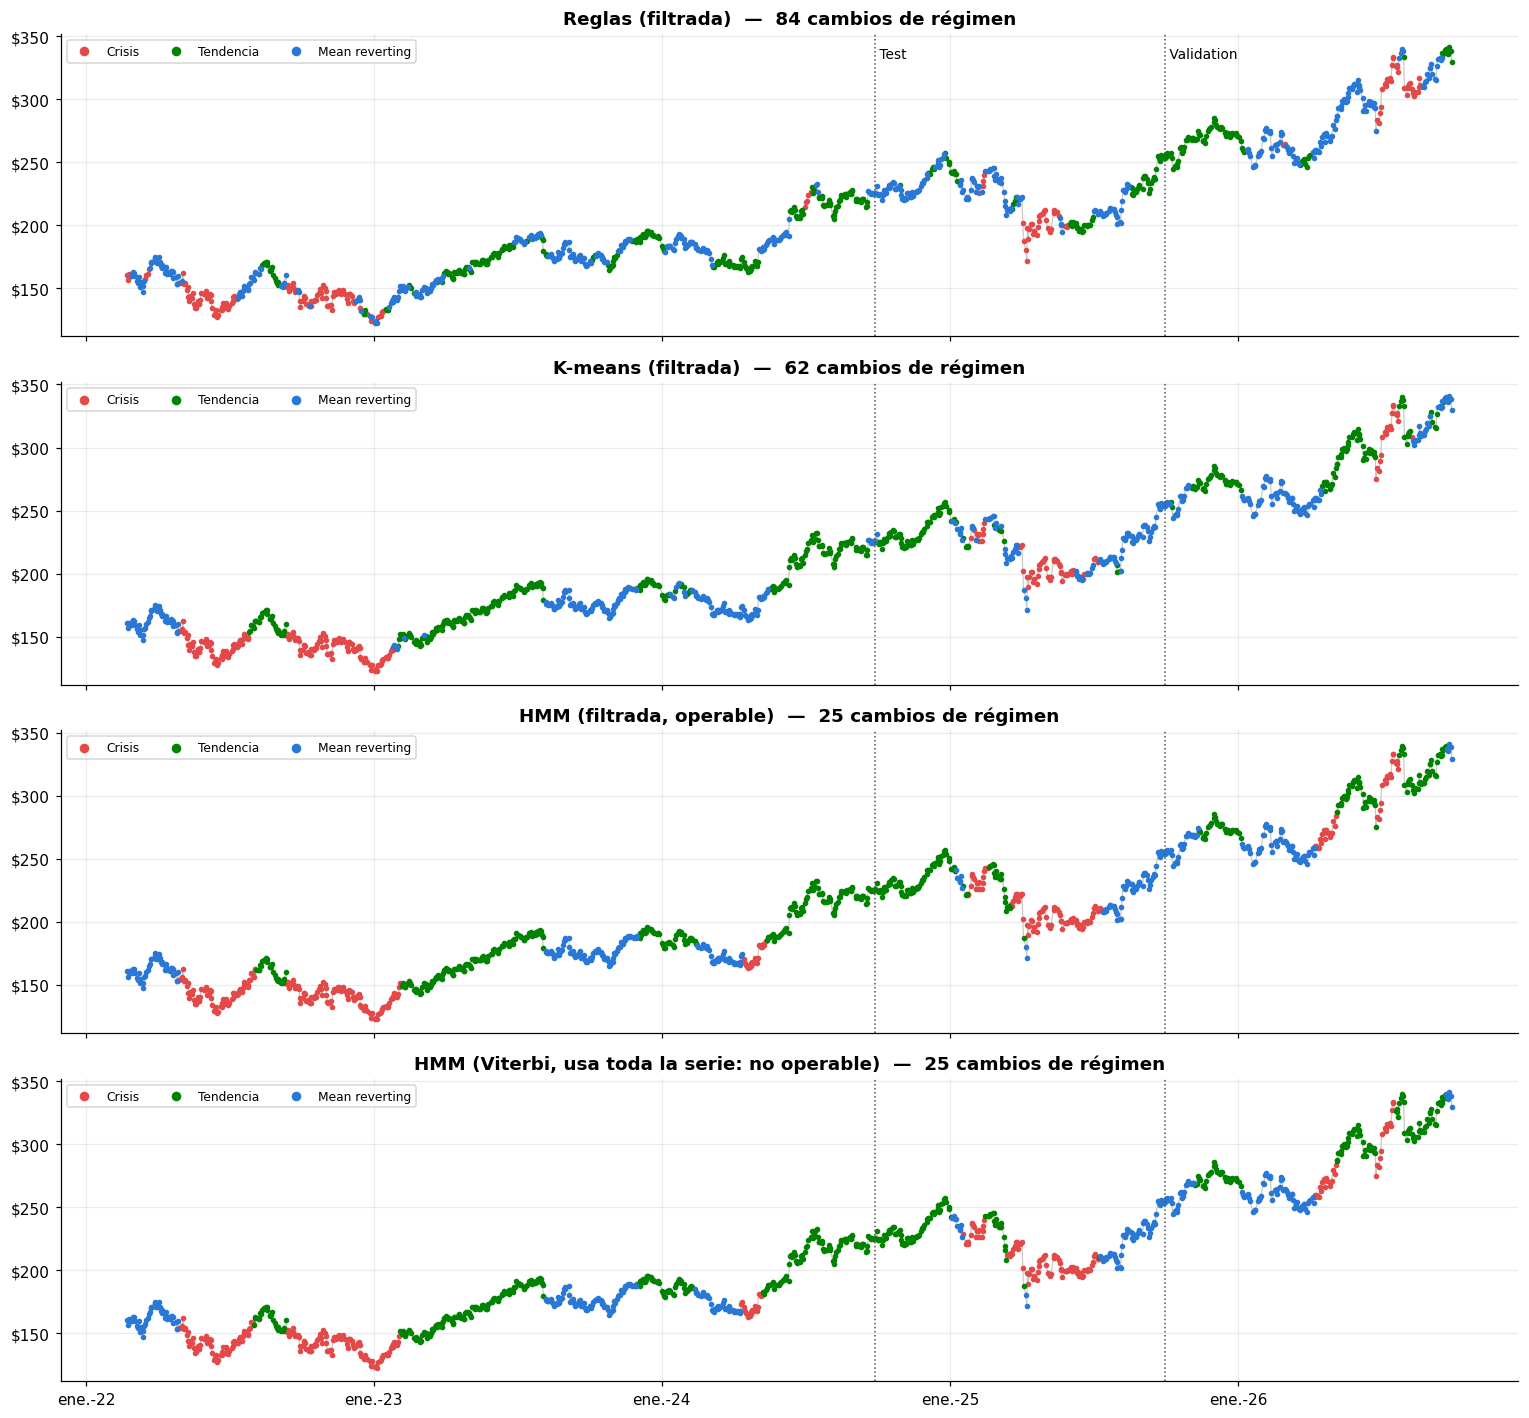

In [50]:
paneles = [("Reglas (filtrada)", "etiqueta_reglas"), ("K-means (filtrada)", "etiqueta_kmeans"),
           ("HMM (filtrada, operable)", "etiqueta_hmm"), ("HMM (Viterbi, usa toda la serie: no operable)", "etiqueta_hmm_viterbi")]
fig, axs = plt.subplots(len(paneles), 1, figsize=(14, 13), sharex=True)
d_ = data.iloc[WARM:]
for ax, (tit, col) in zip(axs, paneles):
    ax.plot(d_.index, d_["close"], color="#c9c8c4", lw=0.8, zorder=1)
    for r in REGIMENES:
        m = d_[col] == r
        ax.scatter(d_.index[m], d_["close"][m], s=7, color=COL_REG[r], label=r, zorder=2)
    cambios = int((d_[col] != d_[col].shift(1)).sum() - 1)
    ax.axvline(df.index[a], color="#52514e", ls=":", lw=1); ax.axvline(df.index[b], color="#52514e", ls=":", lw=1)
    ax.set_title(f"{tit}  —  {cambios} cambios de régimen"); ax.yaxis.set_major_formatter(usd)
    ax.legend(loc="upper left", ncol=3, fontsize=8, markerscale=2)
axs[0].text(df.index[a], d_["close"].max(), " Test", va="top", fontsize=9); axs[0].text(df.index[b], d_["close"].max(), " Validation", va="top", fontsize=9)
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()

## 26. Distribución de las features por régimen y justificación de los nombres

Un nombre está bien puesto si las features del régimen se comportan como dice el nombre:

* **Crisis** → `vol` claramente más alta que en los otros dos.
* **Tendencia** → \|`trend`\| grande (medias separadas) con volatilidad normal.
* **Mean reverting** → `trend` cerca de cero y/o `ac1` más negativa.

Las cajas muestran la distribución en Train (features estandarizadas: 0 = promedio de Train, 1 = una desviación estándar arriba).

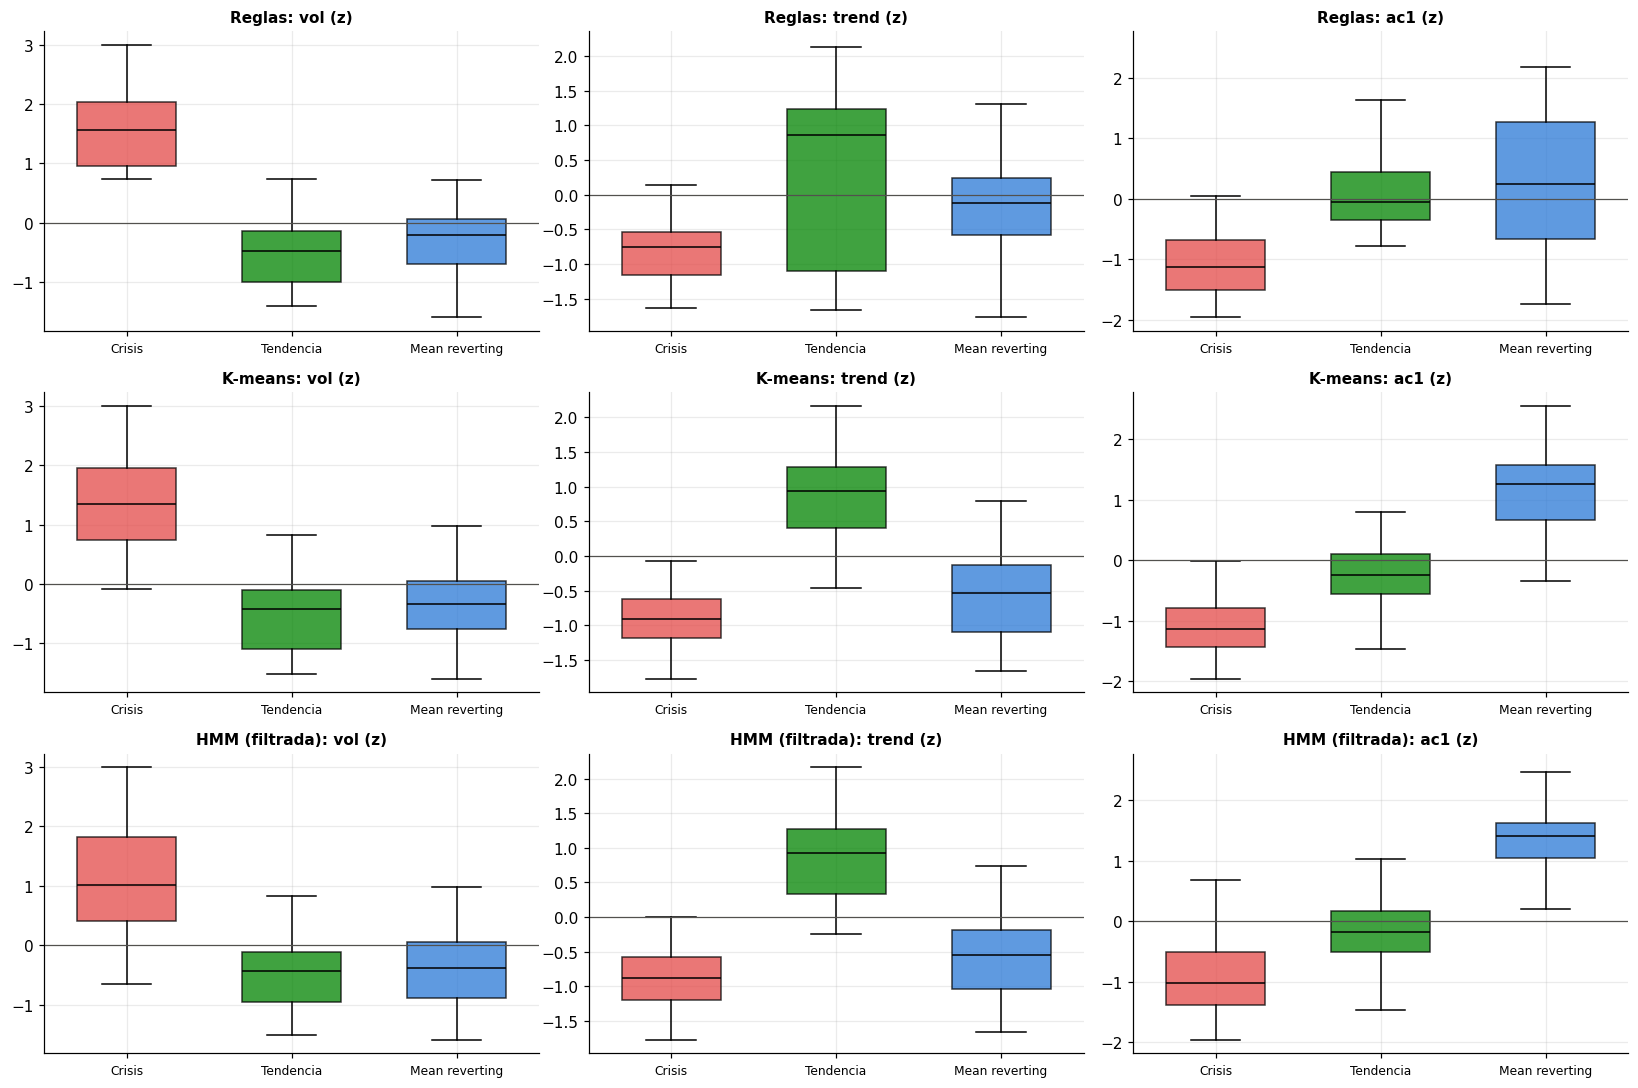

In [51]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10), sharey="col")
for i, (nombre, col) in enumerate(METODOS.items()):
    for j, f in enumerate(FEATURES):
        ax = axs[i, j]
        grupos = [Z_tr.loc[data[col].iloc[WARM:a] == r, f].dropna().to_numpy() for r in REGIMENES]
        bp = ax.boxplot(grupos, patch_artist=True, widths=0.6, showfliers=False, medianprops=dict(color="black"))
        for patch, r in zip(bp["boxes"], REGIMENES): patch.set_facecolor(COL_REG[r]); patch.set_alpha(0.75)
        ax.axhline(0, color="#52514e", lw=0.8)
        ax.set_xticks(range(1, 4), REGIMENES, fontsize=8)
        ax.set_title(f"{nombre}: {f} (z)", fontsize=10)
plt.tight_layout(); plt.show()

In [52]:
# Centroides (media de cada feature por régimen) en Train, en unidades originales y estandarizadas
cent = {}
for nombre, col in METODOS.items():
    lab_tr = data[col].iloc[WARM:a]
    g_z = Z_tr.groupby(lab_tr).mean().reindex(REGIMENES)
    g_o = feats_tr.groupby(lab_tr).mean().reindex(REGIMENES)
    cent[nombre] = pd.DataFrame({"vol (z)": g_z["vol"], "trend (z)": g_z["trend"], "ac1 (z)": g_z["ac1"],
                                 "vol diaria (%)": 100 * g_o["vol"], "trend": g_o["trend"], "|trend| medio": feats_tr["trend"].abs().groupby(lab_tr).mean().reindex(REGIMENES),
                                 "ac1": g_o["ac1"], "Días": lab_tr.value_counts().reindex(REGIMENES)})
centroides = pd.concat(cent)
display(centroides)

# Comprobación automática de que cada nombre es coherente con su centroide
chk = []
for nombre in METODOS:
    c_ = centroides.loc[nombre]
    chk.append({"Método": nombre,
                "Crisis tiene la mayor vol": bool(c_["vol (z)"].idxmax() == "Crisis"),
                "Tendencia tiene mayor |trend| que Mean reverting": bool(c_.loc["Tendencia", "|trend| medio"] > c_.loc["Mean reverting", "|trend| medio"]),
                "Mean reverting tiene menor ac1 que Tendencia": bool(c_.loc["Mean reverting", "ac1"] < c_.loc["Tendencia", "ac1"])})
display(pd.DataFrame(chk).set_index("Método"))

# Rendimiento del día siguiente por régimen (no se usó para ajustar: es una validación externa de las etiquetas)
ret_sig = np.log(df["close"]).diff().shift(-1)
val = {}
for nombre, col in METODOS.items():
    g = ret_sig.iloc[WARM:a].groupby(data[col].iloc[WARM:a])
    val[nombre] = pd.DataFrame({"Rend. medio día siguiente (% anualizado)": 100 * 252 * g.mean(),
                                "Volatilidad día siguiente (% anualizada)": 100 * np.sqrt(252) * g.std()}).reindex(REGIMENES)
print("¿Qué pasa al día siguiente en cada régimen? (Train)"); display(pd.concat(val))

vol (z)  trend (z)  ac1 (z)  vol diaria (%)  \
               etiqueta_reglas                                                
Reglas         Crisis              1.60      -0.77    -0.96            2.59   
               Tendencia          -0.53       0.49     0.18            1.34   
               Mean reverting     -0.29      -0.05     0.29            1.48   
K-means        Crisis              1.39      -0.92    -1.09            2.47   
               Tendencia          -0.50       0.93    -0.27            1.35   
               Mean reverting     -0.33      -0.57     1.12            1.46   
HMM (filtrada) Crisis              1.13      -0.89    -0.91            2.32   
               Tendencia          -0.51       0.91    -0.19            1.35   
               Mean reverting     -0.37      -0.59     1.35            1.43   

                                trend  |trend| medio   ac1  Días  
               etiqueta_reglas                                    
Reglas         Crisis           -2.21           3.05 -0.08   131  
               Tendencia         4.34           6.91  0.05   236  
               Mean reverting    1.50           3.09  0.06   286  
K-means        Crisis           -2.98           3.11 -0.09   153  
               Tendencia         6.63           6.63 -0.00   283  
               Mean reverting   -1.18           2.58  0.15   217  
HMM (filtrada) Crisis           -2.83           3.02 -0.07   188  
               Tendencia         6.47           6.47  0.01   296  
               Mean reverting   -1.30           2.55  0.17   169

,Crisis tiene la mayor vol,Tendencia tiene mayor |trend| que Mean reverting,Mean reverting tiene menor ac1 que Tendencia
Método,,,
Reglas,True,True,False
K-means,True,True,False
HMM (filtrada),True,True,False


¿Qué pasa al día siguiente en cada régimen? (Train)


Rend. medio día siguiente (% anualizado)  \
               etiqueta_reglas                                             
Reglas         Crisis                                               1.22   
               Tendencia                                           15.01   
               Mean reverting                                      17.05   
K-means        Crisis                                             -11.32   
               Tendencia                                           32.33   
               Mean reverting                                       5.36   
HMM (filtrada) Crisis                                              16.31   
               Tendencia                                           22.83   
               Mean reverting                                      -7.35   

                                Volatilidad día siguiente (% anualizada)  
               etiqueta_reglas                                            
Reglas         Crisis                                              37.39  
               Tendencia                                           22.58  
               Mean reverting                                      26.31  
K-means        Crisis                                              38.01  
               Tendencia                                           23.40  
               Mean reverting                                      23.97  
HMM (filtrada) Crisis                                              36.52  
               Tendencia                                           22.52  
               Mean reverting                                      24.35

## 27. Elección del método

**Criterio (definido antes de ver el desempeño de la estrategia):** el mejor etiquetador para operar es el que da regímenes **separados** (silhouette alto), **persistentes** (duración media alta, pocas transiciones por mes) y **con días suficientes en cada estado**. Un método con silhouette alto pero que cambia de etiqueta cada dos días no sirve: la operación promedio dura ~9 días y el régimen cambiaría a media operación.

Procedimiento, solo con Train:
1. Se descarta cualquier método que deje un régimen con menos del 5 % de los días.
2. Entre los que quedan se ordena cada métrica (1 = mejor) y se suman los lugares de silhouette, duración media y transiciones por mes.
3. Gana el de menor suma. En caso de empate se prefiere el HMM, porque es el único que modela la persistencia en el tiempo.

La elección queda guardada en `METODO`; si se quiere usar otro, basta cambiar esa variable y volver a correr desde aquí.

In [53]:
c_ = comp_tr.loc[list(METODOS)].astype(float)
valido = (c_[[f"% {r}" for r in REGIMENES]] >= 5).all(axis=1)
rk = pd.DataFrame({"Lugar silhouette": c_["Silhouette"].rank(ascending=False),
                   "Lugar duración": c_["Duración media (barras)"].rank(ascending=False),
                   "Lugar transiciones": c_["Transiciones por mes"].rank(ascending=True)})
rk["Suma de lugares"] = rk.sum(axis=1)
rk["Todos los regímenes ≥ 5 %"] = valido
cand = rk[valido] if valido.any() else rk
mejores = cand.index[cand["Suma de lugares"] == cand["Suma de lugares"].min()].tolist()
METODO = "HMM (filtrada)" if "HMM (filtrada)" in mejores else mejores[0]
display(rk)

data["etiqueta"] = data[METODOS[METODO]]
s_tr, s_te = comp_tr.loc[METODO], comp_te.loc[METODO]
print(f"MÉTODO ELEGIDO: {METODO}")
print(f"  Train: silhouette {s_tr['Silhouette']:.3f}, duración media {s_tr['Duración media (barras)']:.1f} días, "
      f"{s_tr['Transiciones por mes']:.2f} transiciones por mes")
print(f"  Test:  silhouette {s_te['Silhouette']:.3f}, duración media {s_te['Duración media (barras)']:.1f} días, "
      f"{s_te['Transiciones por mes']:.2f} transiciones por mes")
print("  Participación en Train: " + ", ".join(f"{r} {s_tr[f'% {r}']:.0f}%" for r in REGIMENES))
print(f"  La operación promedio de la estrategia dura {resumen['Holding promedio (barras)']:.1f} días; "
      f"el régimen dura en promedio {s_tr['Duración media (barras)']:.1f} días.")

,Lugar silhouette,Lugar duración,Lugar transiciones,Suma de lugares,Todos los regímenes ≥ 5 %
Reglas,3.00,3.00,3.00,9.00,True
K-means,1.00,2.00,2.00,5.00,True
HMM (filtrada),2.00,1.00,1.00,4.00,True


MÉTODO ELEGIDO: HMM (filtrada)
  Train: silhouette 0.428, duración media 65.3 días, 0.29 transiciones por mes
  Test:  silhouette 0.218, duración media 25.1 días, 0.75 transiciones por mes
  Participación en Train: Crisis 29%, Tendencia 45%, Mean reverting 26%
  La operación promedio de la estrategia dura 8.7 días; el régimen dura en promedio 65.3 días.


## 28. Operar los regímenes: un θ por estado

$$\theta_j^* = \arg\max_{\theta}\; J\big(\text{backtest}(\text{train} \mid s_t = j,\ \theta)\big), \qquad j = \text{Crisis, Tendencia, Mean reverting}$$

**Cómo se optimiza cada θ\*_j:** se corre el backtest en Train permitiendo entradas **solo** cuando la etiqueta filtrada del día de la señal es *j*, y Optuna busca el θ = (SL, TP, BE) que maximiza el Calmar de ese backtest.

**Cómo se opera:** en cada señal se mira la etiqueta filtrada de ese día, ŝ_t, y la operación se abre con θ\*_ŝt. El θ queda fijo durante la operación (el stop y el objetivo no se mueven si el régimen cambia a media operación). El motor es `backtest_regimes()`: el mismo motor orientado a eventos, con una prueba que verifica que da exactamente lo mismo que `backtest()` cuando los tres regímenes usan el mismo θ.

**Decisión por régimen, tomada solo con Train:**

| Situación en Train | Qué se hace |
|---|---|
| Menos de 2 señales en ese régimen | No hay con qué optimizar: se usa el θ\* único |
| J\*_j ≤ 0 (pierde aun con su mejor θ) | **No se opera** en ese régimen |
| El θ\* único da mejor J que el que encontró Optuna | Se conserva el θ\* único |
| J\*_j > 0 | Se usa θ\*_j |

Se compara contra el **θ\* único** de la sección 17 (el de Optuna con todo Train) y contra el θ fijo de la Act 06, en Train y en Test.

> **Antes de leer los resultados, mira la tabla de señales por régimen.** La regla de entrada exige SMA_10 > SMA_100 y momentum positivo, es decir, la estrategia casi solo dispara cuando ya hay tendencia alcista. Es normal que la mayoría de las señales caigan en un solo régimen y que los otros dos tengan 0–2 señales: en ese caso no hay datos para optimizar un θ propio y el θ por régimen termina pareciéndose mucho al θ\* único.

In [54]:
tr7, te7, va7 = data.iloc[WARM:a], data.iloc[a:b], data.iloc[b:]
señales = pd.DataFrame({tramo: d_.loc[d_["entry_trigger"].astype(bool), "etiqueta"].value_counts().reindex(REGIMENES).fillna(0).astype(int)
                        for tramo, d_ in [("Train", tr7), ("Test", te7), ("Validation", va7)]})
print("Señales de entrada por régimen (etiqueta filtrada del día de la señal):"); display(señales)

tabla_reg = optimize_by_regime(tr7, theta_star, "etiqueta", n_trials=150, seed=42, base=P, min_trades=2)
display(tabla_reg)
P_REG = params_from_table(tabla_reg, P)

Señales de entrada por régimen (etiqueta filtrada del día de la señal):


,Train,Test,Validation
etiqueta,,,
Crisis,0,0,1
Tendencia,9,2,1
Mean reverting,0,0,1


,Barras en train,Señales en train,sl_atr,tp_atr,be_atr,J* (Calmar),J con θ* único,Operaciones con θ elegido,Decisión
Régimen,,,,,,,,,
Crisis,188,0,2.25,1.00,2.00,NaN,NaN,0,θ* único (sin señales suficientes)
Tendencia,296,9,2.25,1.00,2.00,1.54,1.54,8,θ* único (ya era el mejor en este régimen)
Mean reverting,169,0,2.25,1.00,2.00,NaN,NaN,0,θ* único (sin señales suficientes)


In [55]:
def evaluar(d_):
    return {"θ por régimen": backtest_regimes(d_, P_REG, "etiqueta", default=P),
            "θ* único (Optuna)": backtest(d_, theta_to_params(theta_star, P)),
            "θ Act 06": backtest(d_, theta_to_params(TH0, P))}

res7 = {tramo: evaluar(d_) for tramo, d_ in [("Train", tr7), ("Test", te7), ("Validation", va7)]}
filas7 = {}
for tramo, rr in res7.items():
    for nombre, r_ in rr.items():
        filas7[(tramo, nombre)] = M.summary(r_)[["Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)", "Calmar",
                                                 "Sharpe (anualizado)", "Operaciones cerradas", "Win rate empírico (%)",
                                                 "Expectancy (R por operación)", "Veredicto (Calmar)"]]
comp7 = pd.DataFrame(filas7)
print("TRAIN (dentro de muestra)"); display(comp7["Train"])
print("TEST (fuera de muestra)"); display(comp7["Test"])
print("VALIDATION (fuera de muestra, no se usó en ningún ajuste)"); display(comp7["Validation"])

TRAIN (dentro de muestra)


,θ por régimen,θ* único (Optuna),θ Act 06
Rendimiento total (%),6.72,6.72,0.86
Rendimiento anualizado CAGR (%),2.54,2.54,0.33
Drawdown máximo (%),-1.65,-1.65,-1.79
Calmar,1.54,1.54,0.18
Sharpe (anualizado),1.11,1.11,0.25
Operaciones cerradas,8,8,6
Win rate empírico (%),100.00,100.00,16.67
Expectancy (R por operación),0.41,0.41,0.07
Veredicto (Calmar),VIABLE,VIABLE,NO VIABLE


TEST (fuera de muestra)


,θ por régimen,θ* único (Optuna),θ Act 06
Rendimiento total (%),1.54,1.54,1.36
Rendimiento anualizado CAGR (%),1.54,1.54,1.36
Drawdown máximo (%),-0.41,-0.41,-0.80
Calmar,3.78,3.78,1.69
Sharpe (anualizado),1.41,1.41,1.13
Operaciones cerradas,2,2,2
Win rate empírico (%),100.00,100.00,50.00
Expectancy (R por operación),0.38,0.38,0.34
Veredicto (Calmar),VIABLE,VIABLE,VIABLE


VALIDATION (fuera de muestra, no se usó en ningún ajuste)


,θ por régimen,θ* único (Optuna),θ Act 06
Rendimiento total (%),2.40,2.40,2.86
Rendimiento anualizado CAGR (%),2.40,2.40,2.87
Drawdown máximo (%),-0.20,-0.20,-1.24
Calmar,11.87,11.87,2.32
Sharpe (anualizado),2.29,2.29,1.78
Operaciones cerradas,3,3,3
Win rate empírico (%),100.00,100.00,66.67
Expectancy (R por operación),0.40,0.40,0.47
Veredicto (Calmar),VIABLE,VIABLE,VIABLE


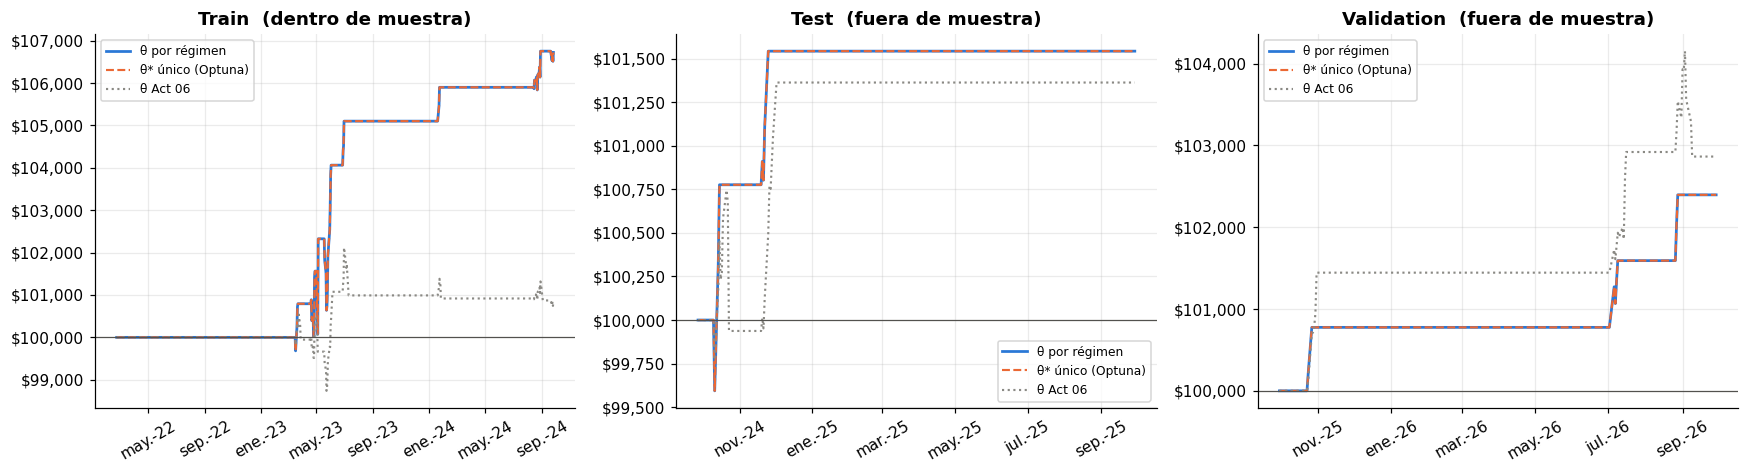

Operaciones de la estrategia con θ por régimen, por tramo y régimen de entrada:


Operaciones  PnL_total  R_promedio  Win_rate
tramo      regimen                                                     
Test       Tendencia                 2   1,543.14        0.38    100.00
Train      Tendencia                 8   6,752.89        0.41    100.00
Validation Crisis                    1     815.62        0.40    100.00
           Mean reverting            1     775.70        0.39    100.00
           Tendencia                 1     803.98        0.40    100.00

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.4))
estilos7 = {"θ por régimen": (BLUE, "-", 1.8), "θ* único (Optuna)": (ORANGE, "--", 1.4), "θ Act 06": (GRAY, ":", 1.4)}
for ax, (tramo, rr) in zip(axs, res7.items()):
    for nombre, r_ in rr.items():
        colr, ls, lw = estilos7[nombre]
        ax.plot(r_["equity"].index, r_["equity"]["equity"], color=colr, ls=ls, lw=lw, label=nombre)
    ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y")); ax.tick_params(axis="x", labelrotation=30)
    ax.set_title(tramo + ("  (dentro de muestra)" if tramo == "Train" else "  (fuera de muestra)")); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Resultado por régimen de la estrategia con θ por régimen
ops = pd.concat([r_["θ por régimen"]["trades"].assign(tramo=tramo) for tramo, r_ in res7.items() if len(r_["θ por régimen"]["trades"])])
if len(ops):
    por_reg = ops.groupby(["tramo", "regimen"]).agg(Operaciones=("pnl", "size"), PnL_total=("pnl", "sum"), R_promedio=("R", "mean"),
                                                    Win_rate=("pnl", lambda s: 100 * (s > 0).mean()))
    print("Operaciones de la estrategia con θ por régimen, por tramo y régimen de entrada:"); display(por_reg)

In [57]:
def g7(tramo, nombre, campo): return comp7[(tramo, nombre)][campo]
resumen7 = pd.DataFrame({"Valor": {
    "Método de etiquetado elegido": METODO,
    "Codo geométrico / k usado": f"{k_codo} / {K}",
    "θ Crisis": f"{tabla_reg.loc['Crisis', 'Decisión']}  ({tabla_reg.loc['Crisis', 'sl_atr']}, {tabla_reg.loc['Crisis', 'tp_atr']}, {tabla_reg.loc['Crisis', 'be_atr']})",
    "θ Tendencia": f"{tabla_reg.loc['Tendencia', 'Decisión']}  ({tabla_reg.loc['Tendencia', 'sl_atr']}, {tabla_reg.loc['Tendencia', 'tp_atr']}, {tabla_reg.loc['Tendencia', 'be_atr']})",
    "θ Mean reverting": f"{tabla_reg.loc['Mean reverting', 'Decisión']}  ({tabla_reg.loc['Mean reverting', 'sl_atr']}, {tabla_reg.loc['Mean reverting', 'tp_atr']}, {tabla_reg.loc['Mean reverting', 'be_atr']})",
    "θ* único (SL, TP, BE)": f"({theta_star['sl_atr']}, {theta_star['tp_atr']}, {theta_star['be_atr']})",
    "Calmar Train: por régimen / único / Act 06": " / ".join(f"{g7('Train', n, 'Calmar'):.2f}" for n in estilos7),
    "Calmar Test: por régimen / único / Act 06": " / ".join(f"{g7('Test', n, 'Calmar'):.2f}" for n in estilos7),
    "Rendimiento Test (%): por régimen / único / Act 06": " / ".join(f"{g7('Test', n, 'Rendimiento total (%)'):+.2f}" for n in estilos7),
    "Operaciones Test: por régimen / único / Act 06": " / ".join(f"{g7('Test', n, 'Operaciones cerradas')}" for n in estilos7),
    "Calmar Validation: por régimen / único / Act 06": " / ".join(f"{g7('Validation', n, 'Calmar'):.2f}" for n in estilos7),
}})
resumen7

,Valor
Método de etiquetado elegido,HMM (filtrada)
Codo geométrico / k usado,3 / 3
θ Crisis,"θ* único (sin señales suficientes) (2.25, 1.0, 2.0)"
θ Tendencia,"θ* único (ya era el mejor en este régimen) (2.25, 1.0, 2.0)"
θ Mean reverting,"θ* único (sin señales suficientes) (2.25, 1.0, 2.0)"
"θ* único (SL, TP, BE)","(2.25, 1.0, 2.0)"
Calmar Train: por régimen / único / Act 06,1.54 / 1.54 / 0.18
Calmar Test: por régimen / único / Act 06,3.78 / 3.78 / 1.69
Rendimiento Test (%): por régimen / único / Act 06,+1.54 / +1.54 / +1.36
Operaciones Test: por régimen / único / Act 06,2 / 2 / 2


## 29. Conclusión de la Act 07

*(Se completa con los resultados de AAPL. Guía para escribirla con las tablas de arriba:)*

1. **Features.** ¿La prueba de truncamiento dio diferencia cero en las tres columnas? (sección 21)
2. **Codo.** ¿El codo geométrico coincide con k = 3? Si no, ¿cuánto baja la inercia de 2 a 3 contra de 3 a 4? (sección 22)
3. **Comparación.** ¿Qué método tiene mejor silhouette y cuál es más persistente? ¿Se mantiene en Test? (sección 24)
4. **Nombres.** ¿La tabla de comprobación de la sección 26 sale toda en `True` para el método elegido?
5. **Método elegido** y por qué (sección 27).
6. **θ por régimen contra θ\* único.** En Train casi siempre gana el θ por régimen (tiene 9 parámetros en vez de 3). Lo que decide es **Test**: si ahí no supera al θ\* único, los regímenes no están aportando y solo se sobreajustó. Revisa también cuántas señales hubo por régimen: con 1 o 2 operaciones por estado, el θ\*_j no es confiable.